In [6]:
# Install required libraries (Colab safe)
!pip install -q datasets transformers matplotlib numpy pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

In [7]:
from datasets import load_dataset

# Load official dataset (27 emotions + neutral)
dataset = load_dataset("google-research-datasets/go_emotions", "simplified")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 43410
    })
    validation: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5426
    })
    test: Dataset({
        features: ['text', 'labels', 'id'],
        num_rows: 5427
    })
})


In [8]:
# Extract label names directly from dataset
EMOTION_NAMES = dataset["train"].features["labels"].feature.names

print("Number of labels:", len(EMOTION_NAMES))
print("Labels:", EMOTION_NAMES)

Number of labels: 28
Labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [9]:
import numpy as np

def encode_labels(example):
    multi = np.zeros(len(EMOTION_NAMES))
    for idx in example["labels"]:
        multi[idx] = 1
    example["multi_labels"] = multi
    return example

dataset = dataset.map(encode_labels)

Map:   0%|          | 0/43410 [00:00<?, ? examples/s]

Map:   0%|          | 0/5426 [00:00<?, ? examples/s]

Map:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [10]:
def analyze_neutral_rows(dataset_split):

    neutral_only = 0
    neutral_plus_other = 0
    no_neutral = 0

    for labels in dataset_split["labels"]:

        if 27 in labels:
            if len(labels) == 1:
                neutral_only += 1
            else:
                neutral_plus_other += 1
        else:
            no_neutral += 1

    total = len(dataset_split)

    print(f"Total samples: {total}")
    print(f"Neutral only rows: {neutral_only}")
    print(f"Neutral + other emotion rows: {neutral_plus_other}")
    print(f"No neutral rows: {no_neutral}")
    print("-" * 40)

    return neutral_only, neutral_plus_other, no_neutral

In [11]:
print("TRAIN SPLIT")
train_counts = analyze_neutral_rows(dataset["train"])

print("VALIDATION SPLIT")
val_counts = analyze_neutral_rows(dataset["validation"])

print("TEST SPLIT")
test_counts = analyze_neutral_rows(dataset["test"])

TRAIN SPLIT
Total samples: 43410
Neutral only rows: 12823
Neutral + other emotion rows: 1396
No neutral rows: 29191
----------------------------------------
VALIDATION SPLIT
Total samples: 5426
Neutral only rows: 1592
Neutral + other emotion rows: 174
No neutral rows: 3660
----------------------------------------
TEST SPLIT
Total samples: 5427
Neutral only rows: 1606
Neutral + other emotion rows: 181
No neutral rows: 3640
----------------------------------------


In [12]:
def remove_neutral_only(example):
    return not (27 in example["labels"] and len(example["labels"]) == 1)

dataset["train"] = dataset["train"].filter(remove_neutral_only)
dataset["validation"] = dataset["validation"].filter(remove_neutral_only)
dataset["test"] = dataset["test"].filter(remove_neutral_only)

Filter:   0%|          | 0/43410 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5426 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5427 [00:00<?, ? examples/s]

In [13]:
def strip_neutral(example):
    example["labels"] = [l for l in example["labels"] if l != 27]
    return example

dataset["train"] = dataset["train"].map(strip_neutral)
dataset["validation"] = dataset["validation"].map(strip_neutral)
dataset["test"] = dataset["test"].map(strip_neutral)

Map:   0%|          | 0/30587 [00:00<?, ? examples/s]

Map:   0%|          | 0/3834 [00:00<?, ? examples/s]

Map:   0%|          | 0/3821 [00:00<?, ? examples/s]

In [14]:
print("Train rows:", len(dataset["train"]))
print("Validation rows:", len(dataset["validation"]))
print("Test rows:", len(dataset["test"]))

Train rows: 30587
Validation rows: 3834
Test rows: 3821


In [15]:
import pandas as pd

In [16]:
EMOTION_NAMES_NO_NEUTRAL = [
    'admiration','amusement','anger','annoyance','approval','caring',
    'confusion','curiosity','desire','disappointment','disapproval',
    'disgust','embarrassment','excitement','fear','gratitude','grief',
    'joy','love','nervousness','optimism','pride','realization',
    'relief','remorse','sadness','surprise'
]

In [17]:
labels = dataset["train"]["labels"]

multi_hot = np.zeros((len(labels), 27))

for i, row in enumerate(labels):
    for label in row:
        multi_hot[i, label] = 1

emotion_counts = multi_hot.sum(axis=0)

distribution_df = pd.DataFrame({
    "Emotion": EMOTION_NAMES_NO_NEUTRAL,
    "Count": emotion_counts
}).sort_values(by="Count", ascending=False)

distribution_df

,Emotion,Count
0,admiration,4130.0
4,approval,2939.0
15,gratitude,2662.0
3,annoyance,2470.0
1,amusement,2328.0
7,curiosity,2191.0
18,love,2086.0
10,disapproval,2022.0
20,optimism,1581.0
2,anger,1567.0


In [18]:
def count_label_types(split, split_name):

    single = 0
    multi = 0

    for row in split["labels"]:
        if len(row) == 1:
            single += 1
        elif len(row) > 1:
            multi += 1

    total = len(split["labels"])

    print(f"\n===== {split_name.upper()} =====")
    print("Total samples:", total)
    print("Single-label samples:", single)
    print("Multi-label samples:", multi)
    print("Single %: {:.2f}%".format(100 * single / total))
    print("Multi %: {:.2f}%".format(100 * multi / total))


count_label_types(dataset["train"], "train")
count_label_types(dataset["validation"], "validation")
count_label_types(dataset["test"], "test")


===== TRAIN =====
Total samples: 30587
Single-label samples: 24820
Multi-label samples: 5767
Single %: 81.15%
Multi %: 18.85%

===== VALIDATION =====
Total samples: 3834
Single-label samples: 3122
Multi-label samples: 712
Single %: 81.43%
Multi %: 18.57%

===== TEST =====
Total samples: 3821
Single-label samples: 3154
Multi-label samples: 667
Single %: 82.54%
Multi %: 17.46%


In [19]:
def neutral_sanity_check(split, split_name):

    neutral_only = 0
    neutral_mixed = 0
    total = len(split["labels"])

    for row in split["labels"]:

        if 27 in row:
            if len(row) == 1:
                neutral_only += 1
            else:
                neutral_mixed += 1

    print(f"\n===== {split_name.upper()} =====")
    print("Total samples:", total)
    print("Neutral only:", neutral_only)
    print("Neutral + other emotion:", neutral_mixed)


neutral_sanity_check(dataset["train"], "train")
neutral_sanity_check(dataset["validation"], "validation")
neutral_sanity_check(dataset["test"], "test")


===== TRAIN =====
Total samples: 30587
Neutral only: 0
Neutral + other emotion: 0

===== VALIDATION =====
Total samples: 3834
Neutral only: 0
Neutral + other emotion: 0

===== TEST =====
Total samples: 3821
Neutral only: 0
Neutral + other emotion: 0


In [20]:
import numpy as np
import pandas as pd

def compute_distribution(split, split_name):

    labels = split["labels"]

    multi_hot = np.zeros((len(labels), 27))

    for i, row in enumerate(labels):
        for label in row:
            multi_hot[i, label] = 1

    counts = multi_hot.sum(axis=0)

    max_count = counts.max()
    min_count = counts.min()
    imbalance_ratio = max_count / min_count

    df = pd.DataFrame({
        "Emotion": EMOTION_NAMES_NO_NEUTRAL,
        "Count": counts
    }).sort_values(by="Count", ascending=False)

    print(f"\n===== {split_name.upper()} =====")
    print("Total samples:", len(labels))
    print("Max samples:", max_count)
    print("Min samples:", min_count)
    print("Imbalance ratio: {:.2f}:1".format(imbalance_ratio))

    return df


train_df = compute_distribution(dataset["train"], "train")
val_df = compute_distribution(dataset["validation"], "validation")
test_df = compute_distribution(dataset["test"], "test")


===== TRAIN =====
Total samples: 30587
Max samples: 4130.0
Min samples: 77.0
Imbalance ratio: 53.64:1

===== VALIDATION =====
Total samples: 3834
Max samples: 488.0
Min samples: 13.0
Imbalance ratio: 37.54:1

===== TEST =====
Total samples: 3821
Max samples: 504.0
Min samples: 6.0
Imbalance ratio: 84.00:1


In [21]:
from collections import Counter
import pandas as pd

emotions = [
"admiration","amusement","anger","annoyance","approval","caring",
"confusion","curiosity","desire","disappointment","disapproval",
"disgust","embarrassment","excitement","fear","gratitude","grief",
"joy","love","nervousness","optimism","pride","realization","relief",
"remorse","sadness","surprise","neutral"
]

def compute_distribution(split_dataset, split_name):

    counter = Counter()

    for example in split_dataset:
        labels = example["labels"]   # neutral already removed by you

        for l in labels:
            counter[l] += 1

    df = pd.DataFrame({
        "emotion":[emotions[i] for i in counter.keys()],
        f"{split_name}_count":list(counter.values())
    }).sort_values(f"{split_name}_count", ascending=False).reset_index(drop=True)

    return df

In [22]:
train_df = compute_distribution(dataset["train"], "train")
val_df   = compute_distribution(dataset["validation"], "validation")
test_df  = compute_distribution(dataset["test"], "test")

BT

In [23]:
# ============================================================
# INSTALL
# ============================================================

!pip install -q transformers datasets torch sentencepiece
!pip install -q sacremoses  # required for MarianMT

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 24.5 MB/s eta 0:00:0000:01


In [24]:
# ============================================================
# EXACT PAPER LANGUAGES — Only confirmed Helsinki-NLP models
# From Radliński et al. 2025
# 8 out of their 10 exist in Helsinki-NLP
# Polish + Hungarian DO NOT EXIST → skipped
# ============================================================

from transformers import MarianMTModel, MarianTokenizer
import torch
import random

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
print("Device:", device)

LANGUAGE_PAIRS = [

    # ── 8 languages from their paper that EXIST ──────

    (
        "Helsinki-NLP/opus-mt-en-hi",
        "Helsinki-NLP/opus-mt-hi-en",
        "HI"
    ),   # Hindi    ✅ confirmed exists

    (
        "Helsinki-NLP/opus-mt-en-ru",
        "Helsinki-NLP/opus-mt-ru-en",
        "RU"
    ),   # Russian  ✅ confirmed exists

    (
        "Helsinki-NLP/opus-mt-en-zh",
        "Helsinki-NLP/opus-mt-zh-en",
        "ZH"
    ),   # Chinese  ✅ confirmed exists

    (
        "Helsinki-NLP/opus-mt-en-es",
        "Helsinki-NLP/opus-mt-es-en",
        "ES"
    ),   # Spanish  ✅ confirmed exists

    (
        "Helsinki-NLP/opus-mt-en-jap",
        "Helsinki-NLP/opus-mt-ja-en",
        "JA"
    ),   # Japanese ✅ confirmed exists

    (
        "Helsinki-NLP/opus-mt-en-ar",
        "Helsinki-NLP/opus-mt-ar-en",
        "AR"
    ),   # Arabic   ✅ confirmed exists

    (
        "Helsinki-NLP/opus-mt-tc-big-en-fi",
        "Helsinki-NLP/opus-mt-tc-big-fi-en",
        "FI"
    ),   # Finnish  ✅ confirmed exists (tc-big)

    (
        "Helsinki-NLP/opus-mt-tc-big-en-tr",
        "Helsinki-NLP/opus-mt-tc-big-tr-en",
        "TR"
    ),   # Turkish  ✅ confirmed exists (tc-big)


]

print("\nLoading translation models...")
print(f"Loading 8 languages from paper\n"
      f"(Polish + Hungarian not available "
      f"in Helsinki-NLP)\n")

loaded_models = []

for i, (fwd_name, bwd_name, lang) in enumerate(
    LANGUAGE_PAIRS
):
    print(f"Loading {lang} pair "
          f"({i+1}/{len(LANGUAGE_PAIRS)})...")

    try:
        fwd_tokenizer = MarianTokenizer.from_pretrained(
            fwd_name
        )
        fwd_model = MarianMTModel.from_pretrained(
            fwd_name
        ).to(device)
        fwd_model.eval()

        bwd_tokenizer = MarianTokenizer.from_pretrained(
            bwd_name
        )
        bwd_model = MarianMTModel.from_pretrained(
            bwd_name
        ).to(device)
        bwd_model.eval()

        loaded_models.append({
            "lang":          lang,
            "fwd_tokenizer": fwd_tokenizer,
            "fwd_model":     fwd_model,
            "bwd_tokenizer": bwd_tokenizer,
            "bwd_model":     bwd_model
        })

        print(f"  ✅ {lang} loaded")

    except Exception as e:
        print(f"  ❌ {lang} FAILED — skipping")
        print(f"     Reason: {e}")

print(f"\n✅ {len(loaded_models)} language pairs loaded")
print(f"Languages: "
      f"{[m['lang'] for m in loaded_models]}")


Device: cuda

Loading translation models...
Loading 8 languages from paper
(Polish + Hungarian not available in Helsinki-NLP)

Loading HI pair (1/8)...


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/812k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/470M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

  ✅ TR loaded

✅ 8 language pairs loaded
Languages: ['HI', 'RU', 'ZH', 'ES', 'JA', 'AR', 'FI', 'TR']


In [27]:
import numpy as np

TARGET_MIN = 1000

texts  = list(dataset["train"]["text"])
labels = list(dataset["train"]["labels"])

# Recompute counts
counts = np.zeros(27)

for row in labels:
    for l in row:
        counts[l] += 1

print("Current Counts:\n")
for i, c in enumerate(counts):
    print(f"  {EMOTION_NAMES_NO_NEUTRAL[i]}: {int(c)}")

# Recompute deficit
deficit = {}

for i, c in enumerate(counts):
    if c < TARGET_MIN:
        deficit[i] = int(TARGET_MIN - c)

print("\nClasses needing augmentation:\n")
for k, v in deficit.items():
    print(f"  {EMOTION_NAMES_NO_NEUTRAL[k]}"
          f" → needs {v} samples")

print(f"\nTotal samples to generate: {sum(deficit.values())}")

Current Counts:

  admiration: 4130
  amusement: 2328
  anger: 1567
  annoyance: 2470
  approval: 2939
  caring: 1087
  confusion: 1368
  curiosity: 2191
  desire: 641
  disappointment: 1269
  disapproval: 2022
  disgust: 793
  embarrassment: 303
  excitement: 853
  fear: 596
  gratitude: 2662
  grief: 77
  joy: 1452
  love: 2086
  nervousness: 164
  optimism: 1581
  pride: 111
  realization: 1110
  relief: 153
  remorse: 545
  sadness: 1326
  surprise: 1060

Classes needing augmentation:

  desire → needs 359 samples
  disgust → needs 207 samples
  embarrassment → needs 697 samples
  excitement → needs 147 samples
  fear → needs 404 samples
  grief → needs 923 samples
  nervousness → needs 836 samples
  pride → needs 889 samples
  relief → needs 847 samples
  remorse → needs 455 samples

Total samples to generate: 5764


In [28]:
# ============================================================
# BACK-TRANSLATION FUNCTION
# English → Foreign Language → English
# ============================================================

def translate(texts, tokenizer, model, batch_size=32):
    """Translate a list of texts using MarianMT"""

    all_translations = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i + batch_size]

        inputs = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=128
        ).to(device)

        with torch.no_grad():
            translated = model.generate(
                **inputs,
                num_beams=4,           # beam search for quality
                max_length=128,
                early_stopping=True
            )

        decoded = tokenizer.batch_decode(
            translated,
            skip_special_tokens=True
        )

        all_translations.extend(decoded)

    return all_translations


def back_translate(text, lang_pair):
    """
    Translate English text to foreign language
    then back to English
    Returns back-translated text
    """

    # Step 1 — English → Foreign
    foreign = translate(
        [text],
        lang_pair["fwd_tokenizer"],
        lang_pair["fwd_model"]
    )[0]

    # Step 2 — Foreign → English
    back_english = translate(
        [foreign],
        lang_pair["bwd_tokenizer"],
        lang_pair["bwd_model"]
    )[0]

    return back_english


def back_translate_batch(texts, lang_pair):
    """
    Batch version — much faster for large lists
    Translate entire list at once
    """

    # Step 1 — English → Foreign (batch)
    foreign_texts = translate(
        texts,
        lang_pair["fwd_tokenizer"],
        lang_pair["fwd_model"]
    )

    # Step 2 — Foreign → English (batch)
    back_english_texts = translate(
        foreign_texts,
        lang_pair["bwd_tokenizer"],
        lang_pair["bwd_model"]
    )

    return back_english_texts

In [29]:
# ============================================================
# SANITY CHECK — Verify back-translation works
# Run this before full augmentation
# ============================================================

print("===== BACK-TRANSLATION SANITY CHECK =====\n")

test_sentences = [
    "I feel so sad and empty inside",
    "This is the worst day of my life",
    "I cannot believe they are gone forever",
    "I am so embarrassed about what happened",
    "Why do I always feel so nervous?",
    "I miss them so much it hurts",
    "I feel proud of what I accomplished today",
    "This whole situation makes me uncomfortable"
]

print(f"{'ORIGINAL':<45} | {'LANGUAGE':<8} | {'BACK-TRANSLATED':<45} | SAME?")
print("-" * 110)

identical_count = 0
different_count = 0

for sent in test_sentences:

    # Test with first language only for speed
    lang_pair = loaded_models[0]
    bt = back_translate(sent, lang_pair)

    is_same = (sent.lower().strip() == bt.lower().strip())

    if is_same:
        identical_count += 1
        flag = "❌ SAME"
    else:
        different_count += 1
        flag = "✅ DIFF"

    print(f"{sent[:43]:<45} | "
          f"{lang_pair['lang'].upper():<8} | "
          f"{bt[:43]:<45} | "
          f"{flag}")

print(f"\nIdentical: {identical_count}/{len(test_sentences)}")
print(f"Different: {different_count}/{len(test_sentences)}")
print("\nExpected: mostly DIFFERENT ✅")
print("Back-translation rewrites entire sentence")
print("unlike MLM which changes only 1 token")

===== BACK-TRANSLATION SANITY CHECK =====

ORIGINAL                                      | LANGUAGE | BACK-TRANSLATED                               | SAME?
--------------------------------------------------------------------------------------------------------------
I feel so sad and empty inside                | HI       | I feel so sad and empty inside                | ❌ SAME
This is the worst day of my life              | HI       | This is the worst day of my life              | ❌ SAME
I cannot believe they are gone forever        | HI       | I can't believe they're running forever       | ✅ DIFF
I am so embarrassed about what happened       | HI       | I am so sorry about what happened             | ✅ DIFF
Why do I always feel so nervous?              | HI       | Why am I always so upset?                     | ✅ DIFF
I miss them so much it hurts                  | HI       | I miss them so much pain                      | ✅ DIFF
I feel proud of what I accomplished today     | H

In [30]:
# ============================================================
# BACK-TRANSLATION AUGMENTATION

# ============================================================

import random
import numpy as np

augmented_texts  = []
augmented_labels = []
source_texts     = []   # track originals for sanity check

print("===== BACK-TRANSLATION AUGMENTATION =====\n")
print(f"Using {len(loaded_models)} languages: "
      f"{[m['lang'].upper() for m in loaded_models]}\n")

for class_idx, needed in deficit.items():

    class_name = EMOTION_NAMES_NO_NEUTRAL[class_idx]

    print(f"\n{'='*50}")
    print(f"Class: {class_name} | Need: {needed} samples")
    print(f"{'='*50}")

    # Collect all training samples for this class
    class_samples = [
        (text, lbl)
        for text, lbl in zip(texts, labels)
        if class_idx in lbl
    ]

    print(f"Source pool: {len(class_samples)} original samples")

    generated = 0

    # How many samples per language
    per_language = needed // len(loaded_models)
    remainder    = needed %  len(loaded_models)

    for lang_idx, lang_pair in enumerate(loaded_models):

        # Last language gets the remainder
        n_this_lang = per_language
        if lang_idx == len(loaded_models) - 1:
            n_this_lang += remainder

        print(f"  {lang_pair['lang'].upper()}: "
              f"generating {n_this_lang} samples...")

        # Sample source texts for this language
        sampled = random.choices(class_samples, k=n_this_lang)
        batch_texts  = [s[0] for s in sampled]
        batch_labels = [s[1] for s in sampled]

        # Back-translate entire batch at once (fast)
        bt_texts = back_translate_batch(batch_texts, lang_pair)

        # Store results
        augmented_texts.extend(bt_texts)
        augmented_labels.extend(batch_labels)
        source_texts.extend(batch_texts)

        generated += n_this_lang
        print(f"  ✅ {lang_pair['lang'].upper()} done "
              f"({generated}/{needed})")

    print(f"✅ {class_name} complete: {generated} samples generated")

print(f"\n{'='*50}")
print(f"AUGMENTATION COMPLETE")
print(f"Total augmented samples: {len(augmented_texts)}")
print(f"{'='*50}")

===== BACK-TRANSLATION AUGMENTATION =====

Using 8 languages: ['HI', 'RU', 'ZH', 'ES', 'JA', 'AR', 'FI', 'TR']


Class: desire | Need: 359 samples
Source pool: 641 original samples
  HI: generating 44 samples...
  ✅ HI done (44/359)
  RU: generating 44 samples...
  ✅ RU done (88/359)
  ZH: generating 44 samples...
  ✅ ZH done (132/359)
  ES: generating 44 samples...
  ✅ ES done (176/359)
  JA: generating 44 samples...
  ✅ JA done (220/359)
  AR: generating 44 samples...
  ✅ AR done (264/359)
  FI: generating 44 samples...
  ✅ FI done (308/359)
  TR: generating 51 samples...
  ✅ TR done (359/359)
✅ desire complete: 359 samples generated

Class: disgust | Need: 207 samples
Source pool: 793 original samples
  HI: generating 25 samples...
  ✅ HI done (25/207)
  RU: generating 25 samples...
  ✅ RU done (50/207)
  ZH: generating 25 samples...
  ✅ ZH done (75/207)
  ES: generating 25 samples...
  ✅ ES done (100/207)
  JA: generating 25 samples...
  ✅ JA done (125/207)
  AR: generating 25 samp

In [31]:
# ============================================================
# POST-AUGMENTATION CHECKS
# 1. Duplicate rate
# 2. Word difference distribution
# 3. Per-class diversity
# ============================================================

print("===== POST-AUGMENTATION QUALITY CHECK =====\n")

# ── Check 1: Exact duplicate rate ──────────────────────────

original_set = set(t.lower().strip() for t in texts)

exact_duplicates  = 0
genuinely_different = 0

for aug in augmented_texts:
    if aug.lower().strip() in original_set:
        exact_duplicates += 1
    else:
        genuinely_different += 1

print("── 1. Exact Duplicate Check ──")
print(f"Total augmented:      {len(augmented_texts)}")
print(f"Exact duplicates:     {exact_duplicates} "
      f"({100*exact_duplicates/len(augmented_texts):.1f}%)")
print(f"Genuinely different:  {genuinely_different} "
      f"({100*genuinely_different/len(augmented_texts):.1f}%)")
print()

# Expected for back-translation:
# Exact duplicates: < 5%
# Genuinely different: > 95%
# vs MLM: 90% were 1-word changes = near-duplicates


# ── Check 2: Word difference distribution ──────────────────

def count_word_diff(s1, s2):
    w1 = s1.lower().strip().split()
    w2 = s2.lower().strip().split()
    if len(w1) != len(w2):
        # different length = many changes
        return max(abs(len(w1)-len(w2)), 3)
    return sum(a != b for a, b in zip(w1, w2))

print("── 2. Word Difference Distribution ──")

diff_counts = {0:0, 1:0, 2:0, 3:0, "4+":0}

check_n = min(500, len(augmented_texts))

for i in range(check_n):
    diff = count_word_diff(source_texts[i],
                           augmented_texts[i])
    if   diff == 0: diff_counts[0]  += 1
    elif diff == 1: diff_counts[1]  += 1
    elif diff == 2: diff_counts[2]  += 1
    elif diff == 3: diff_counts[3]  += 1
    else:           diff_counts["4+"] += 1

print(f"Checked {check_n} samples:\n")
for k, v in diff_counts.items():
    bar = "█" * (v * 40 // check_n)
    print(f"  {k} words changed: "
          f"{v:4d} ({100*v/check_n:5.1f}%) {bar}")




# ── Check 3: Per-class diversity ───────────────────────────

print("── 3. Per-Class Diversity ──\n")
print(f"{'Emotion':<15} | "
      f"{'Orig':>5} | "
      f"{'Needed':>7} | "
      f"{'Unique Aug':>10} | "
      f"{'Diversity':>10} | "
      f"{'Avg Variants':>12}")
print("-" * 75)

aug_ptr = 0

for class_idx, needed in deficit.items():

    name = EMOTION_NAMES_NO_NEUTRAL[class_idx]

    class_aug = augmented_texts[aug_ptr:aug_ptr + needed]
    aug_ptr  += needed

    unique_aug = len(set(
        t.lower().strip() for t in class_aug
    ))

    orig_count = int(counts[class_idx])
    diversity  = 100 * unique_aug / len(class_aug)
    avg_var    = needed / orig_count

    print(f"{name:<15} | "
          f"{orig_count:>5} | "
          f"{needed:>7} | "
          f"{unique_aug:>10} | "
          f"{diversity:>9.1f}% | "
          f"{avg_var:>12.2f}")

print()

print("Grief should now have genuinely varied sentences")


===== POST-AUGMENTATION QUALITY CHECK =====

── 1. Exact Duplicate Check ──
Total augmented:      5764
Exact duplicates:     162 (2.8%)
Genuinely different:  5602 (97.2%)

── 2. Word Difference Distribution ──
Checked 500 samples:

  0 words changed:   10 (  2.0%) 
  1 words changed:   24 (  4.8%) █
  2 words changed:   17 (  3.4%) █
  3 words changed:  253 ( 50.6%) ████████████████████
  4+ words changed:  196 ( 39.2%) ███████████████
── 3. Per-Class Diversity ──

Emotion         |  Orig |  Needed | Unique Aug |  Diversity | Avg Variants
---------------------------------------------------------------------------
desire          |   641 |     359 |        349 |      97.2% |         0.56
disgust         |   793 |     207 |        199 |      96.1% |         0.26
embarrassment   |   303 |     697 |        603 |      86.5% |         2.30
excitement      |   853 |     147 |        141 |      95.9% |         0.17
fear            |   596 |     404 |        386 |      95.5% |         0.68
grie

In [32]:
# ============================================================
# VISUAL COMPARISON — Source vs Back-Translated
# ============================================================

print("===== SOURCE vs BACK-TRANSLATED (20 samples) =====\n")
print(f"{'SOURCE':<50} | {'BACK-TRANSLATED':<50} | DIFF")
print("-" * 115)

sample_idx = random.sample(
    range(len(augmented_texts)), 20
)

for idx in sample_idx:
    src = source_texts[idx]
    aug = augmented_texts[idx]
    diff = count_word_diff(src, aug)

    print(f"{src[:48]:<50} | "
          f"{aug[:48]:<50} | "
          f"{diff} words")



===== SOURCE vs BACK-TRANSLATED (20 samples) =====

SOURCE                                             | BACK-TRANSLATED                                    | DIFF
-------------------------------------------------------------------------------------------------------------------
Whew. I'm safe then.                               | Then I'm safe.                                     | 3 words
They really aren’t people. They were slavers. Ci   | They are not really people, they were slaves. Ci   | 3 words
Im always worrying about the same thing, thats w   | I'm always worried about the same thing, so I al   | 3 words
He will, I feel like it's Christmas Eve and I'm    | It's, I feel like it's Christmas Eve and I'm wai   | 3 words
I've always wanted to eat Youngstown State's mas   | I've always wanted to eat the Yangstown talisman   | 3 words
Sorry, but isn't this a little too obvious? As t   | I'm sorry, but isn't this too obvious?             | 11 words
I'd worry about traffic more than th

In [33]:
# ============================================================
# 10 FULL SENTENCE EXAMPLES
# Original vs Back-Translated
# One example per language
# ============================================================

print("=" * 80)
print("ORIGINAL vs BACK-TRANSLATED — 10 FULL EXAMPLES")
print("=" * 80)

# Pick 10 random samples from your training data
# covering different emotions

import random

# Sample indices covering different emotions
sample_texts = [
    # pick one from each emotion type
    random.choice([t for t, l in zip(texts, labels)
                   if 16 in l]),   # grief
    random.choice([t for t, l in zip(texts, labels)
                   if 19 in l]),   # nervousness
    random.choice([t for t, l in zip(texts, labels)
                   if 21 in l]),   # pride
    random.choice([t for t, l in zip(texts, labels)
                   if 23 in l]),   # relief
    random.choice([t for t, l in zip(texts, labels)
                   if 12 in l]),   # embarrassment
    random.choice([t for t, l in zip(texts, labels)
                   if 8  in l]),   # desire
    random.choice([t for t, l in zip(texts, labels)
                   if 14 in l]),   # fear
    random.choice([t for t, l in zip(texts, labels)
                   if 11 in l]),   # disgust
    random.choice([t for t, l in zip(texts, labels)
                   if 24 in l]),   # remorse
    random.choice([t for t, l in zip(texts, labels)
                   if 13 in l]),   # excitement
]

emotion_names = [
    "grief",       "nervousness", "pride",
    "relief",      "embarrassment", "desire",
    "fear",        "disgust",     "remorse",
    "excitement"
]

# Use one different language per example
lang_indices = list(range(min(10, len(loaded_models))))
# if fewer than 10 languages loaded repeat some
while len(lang_indices) < 10:
    lang_indices.append(
        lang_indices[len(lang_indices)
                     % len(loaded_models)]
    )

print()

for i, (text, emotion) in enumerate(
    zip(sample_texts, emotion_names)
):
    lang_pair = loaded_models[lang_indices[i]]
    lang      = lang_pair["lang"]

    # Forward: English → Foreign
    foreign_batch = translate(
        [text],
        lang_pair["fwd_tokenizer"],
        lang_pair["fwd_model"]
    )
    foreign = foreign_batch[0]

    # Backward: Foreign → English
    back_batch = translate(
        [foreign],
        lang_pair["bwd_tokenizer"],
        lang_pair["bwd_model"]
    )
    back = back_batch[0]

    # Word difference count
    w1   = text.lower().strip().split()
    w2   = back.lower().strip().split()
    diff = sum(
        a != b for a, b in zip(w1, w2)
    ) + abs(len(w1) - len(w2))

    same = (
        text.lower().strip() ==
        back.lower().strip()
    )

    print(f"Example {i+1:2d} — "
          f"EMOTION: {emotion.upper():<15} "
          f"LANGUAGE: {lang}")
    print(f"  ORIGINAL:    {text}")
    print(f"  FOREIGN:     {foreign}")
    print(f"  AUGMENTED:   {back}")
    print(f"  Words changed: {diff}  |  "
          f"{'❌ IDENTICAL' if same else '✅ DIFFERENT'}")
    print()

print("=" * 80)
print("SUMMARY")
print("=" * 80)
print(f"Total examples shown: 10")
print(f"Languages used: "
      f"{[loaded_models[i]['lang'] for i in lang_indices[:10]]}")
print(f"Emotions covered: {emotion_names}")


ORIGINAL vs BACK-TRANSLATED — 10 FULL EXAMPLES

Example  1 — EMOTION: GRIEF           LANGUAGE: HI
  ORIGINAL:    I’m very sorry for the loss of your friend.
  FOREIGN:     मैं अपने दोस्त की मौत के लिए बहुत शर्मिंदा हूँ ।
  AUGMENTED:   I am so sorry for the death of my friend.
  Words changed: 10  |  ✅ DIFFERENT

Example  2 — EMOTION: NERVOUSNESS     LANGUAGE: RU
  ORIGINAL:    Just the name of it gives me anxiety
  FOREIGN:     Просто название меня беспокоит.
  AUGMENTED:   I'm just worried about the name.
  Words changed: 8  |  ✅ DIFFERENT

Example  3 — EMOTION: PRIDE           LANGUAGE: ZH
  ORIGINAL:    I was just kind of born into it, although ironically I was raised a cubs fan as well.
  FOREIGN:     虽然讽刺的是,我也长大了一只小熊的粉丝。
  AUGMENTED:   Ironically, I grew up with a bear fan.
  Words changed: 18  |  ✅ DIFFERENT

Example  4 — EMOTION: RELIEF          LANGUAGE: ES
  ORIGINAL:    At least she can eat Abel or something so we don't have to worry about feeding her.
  FOREIGN:     Al men

In [34]:
print(f"Augmented generated: {len(augmented_texts)}")

Augmented generated: 5764


In [35]:
# ============================================================
# COSINE SIMILARITY CHECK
# Measure how much meaning is preserved
# after back-translation
# Compare with paper: MarianMT = 0.4758
# ============================================================

from transformers import BertTokenizer, BertModel
import torch
import numpy as np

print("Loading BERT for similarity check...")

sim_tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)
sim_model = BertModel.from_pretrained(
    "bert-base-uncased"
).to(device)
sim_model.eval()

print("✅ BERT loaded for similarity\n")

def get_sentence_embedding(text):
    """Get CLS embedding for a sentence"""
    inputs = sim_tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = sim_model(**inputs)

    # CLS token embedding
    cls_embedding = outputs.last_hidden_state[
        :, 0, :
    ].squeeze()

    return cls_embedding.cpu().numpy()


def cosine_similarity(vec1, vec2):
    """Compute cosine similarity between two vectors"""
    dot   = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)

    if norm1 == 0 or norm2 == 0:
        return 0.0

    return dot / (norm1 * norm2)


# ============================================================
# COMPUTE SIMILARITY FOR SAMPLE
# Check 200 samples (full = slow)
# ============================================================

print("Computing cosine similarity...")
print("Checking 200 random samples...\n")

CHECK_N = 200

# Random sample indices
sample_idx = np.random.choice(
    len(augmented_texts),
    size=min(CHECK_N, len(augmented_texts)),
    replace=False
)

similarities = []

for i, idx in enumerate(sample_idx):

    src = source_texts[idx]
    aug = augmented_texts[idx]

    # Get embeddings
    src_emb = get_sentence_embedding(src)
    aug_emb = get_sentence_embedding(aug)

    # Cosine similarity
    sim = cosine_similarity(src_emb, aug_emb)
    similarities.append(sim)

    if (i + 1) % 50 == 0:
        print(f"  Processed {i+1}/{CHECK_N}...")

similarities = np.array(similarities)

# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 60)
print("COSINE SIMILARITY RESULTS")
print("=" * 60)

print(f"\nSamples checked:     {CHECK_N}")
print(f"Mean similarity:     {similarities.mean():.4f}")
print(f"Median similarity:   {np.median(similarities):.4f}")
print(f"Std deviation:       {similarities.std():.4f}")
print(f"Min similarity:      {similarities.min():.4f}")
print(f"Max similarity:      {similarities.max():.4f}")

print(f"\nComparison with paper:")
print(f"  MarianMT (paper):  0.4758")
print(f"  Your MarianMT:     {similarities.mean():.4f}")

if similarities.mean() > 0.4758:
    print(f"  ✅ BETTER than paper's MarianMT")
elif similarities.mean() > 0.40:
    print(f"  ⚠️ Similar to paper's MarianMT")
else:
    print(f"  ❌ Lower than paper's MarianMT")

# Distribution
print(f"\nSimilarity Distribution:")
print(f"  > 0.8  (high fidelity):    "
      f"{(similarities > 0.8).sum():4d} "
      f"({100*(similarities > 0.8).mean():.1f}%)")
print(f"  0.6-0.8 (moderate):        "
      f"{((similarities >= 0.6) & (similarities <= 0.8)).sum():4d} "
      f"({100*((similarities >= 0.6) & (similarities <= 0.8)).mean():.1f}%)")
print(f"  0.4-0.6 (low fidelity):    "
      f"{((similarities >= 0.4) & (similarities < 0.6)).sum():4d} "
      f"({100*((similarities >= 0.4) & (similarities < 0.6)).mean():.1f}%)")
print(f"  < 0.4  (meaning drifted):  "
      f"{(similarities < 0.4).sum():4d} "
      f"({100*(similarities < 0.4).mean():.1f}%)")

Loading BERT for similarity check...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ BERT loaded for similarity

Computing cosine similarity...
Checking 200 random samples...

  Processed 50/200...
  Processed 100/200...
  Processed 150/200...
  Processed 200/200...

COSINE SIMILARITY RESULTS

Samples checked:     200
Mean similarity:     0.9097
Median similarity:   0.9362
Std deviation:       0.0955
Min similarity:      0.3963
Max similarity:      1.0000

Comparison with paper:
  MarianMT (paper):  0.4758
  Your MarianMT:     0.9097
  ✅ BETTER than paper's MarianMT

Similarity Distribution:
  > 0.8  (high fidelity):     179 (89.5%)
  0.6-0.8 (moderate):          17 (8.5%)
  0.4-0.6 (low fidelity):       3 (1.5%)
  < 0.4  (meaning drifted):     1 (0.5%)


In [36]:
# ============================================================
# SENTENCE TRANSFORMERS — Same as paper
# Only needed if you want direct comparison
# ============================================================

!pip install sentence-transformers -q

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Same model type paper likely used
st_model = SentenceTransformer(
    "all-mpnet-base-v2"
)

print("Computing with Sentence Transformers...")

CHECK_N = 200
sample_idx = np.random.choice(
    len(augmented_texts),
    size=CHECK_N,
    replace=False
)

src_samples = [source_texts[i]
               for i in sample_idx]
aug_samples = [augmented_texts[i]
               for i in sample_idx]

# Get embeddings
src_embs = st_model.encode(
    src_samples,
    show_progress_bar=True
)
aug_embs = st_model.encode(
    aug_samples,
    show_progress_bar=True
)

# Cosine similarity
sims = [
    cosine_similarity(
        [src_embs[i]],
        [aug_embs[i]]
    )[0][0]
    for i in range(CHECK_N)
]

sims = np.array(sims)

print("\n" + "=" * 60)
print("SENTENCE TRANSFORMER SIMILARITY")
print("Comparable with paper results")
print("=" * 60)
print(f"\nMean similarity:   {sims.mean():.4f}")
print(f"Paper MarianMT:    0.4758")
print(f"Paper DeepL:       0.8733")

if sims.mean() > 0.4758:
    diff = sims.mean() - 0.4758
    print(f"\n✅ Your score is +{diff:.4f} "
          f"better than paper MarianMT")
elif sims.mean() > 0.40:
    print(f"\n⚠️ Similar to paper MarianMT")
else:
    print(f"\n❌ Lower than paper MarianMT")




modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Computing with Sentence Transformers...


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


SENTENCE TRANSFORMER SIMILARITY
Comparable with paper results

Mean similarity:   0.6467
Paper MarianMT:    0.4758
Paper DeepL:       0.8733

✅ Your score is +0.1709 better than paper MarianMT


In [39]:
# ============================================================
# MEANING DRIFT ANALYSIS
# Based on Sentence Transformer scores (0.6467)
# Show distribution + worst drifted examples
# ============================================================

import numpy as np

print("=" * 60)
print("MEANING DRIFT ANALYSIS")
print("Based on Sentence Transformer Scores")
print("=" * 60)

# ── Recompute using Sentence Transformers ─────────────────
# (comparable with paper's 0.4758)

print("\nComputing ST similarity for all samples...")
print(f"Total: {len(augmented_texts)} samples\n")

st_scores = []

# Batch processing — faster
BATCH_SIZE = 64

for i in range(0, len(augmented_texts), BATCH_SIZE):

    src_batch = source_texts[i:i + BATCH_SIZE]
    aug_batch = augmented_texts[i:i + BATCH_SIZE]

    src_embs = st_model.encode(
        src_batch,
        show_progress_bar=False
    )
    aug_embs = st_model.encode(
        aug_batch,
        show_progress_bar=False
    )

    for j in range(len(src_batch)):
        from sklearn.metrics.pairwise import (
            cosine_similarity as cos_sim
        )
        sim = cos_sim(
            [src_embs[j]],
            [aug_embs[j]]
        )[0][0]
        st_scores.append(sim)

    if (i + BATCH_SIZE) % 500 == 0:
        print(f"  Processed "
              f"{min(i+BATCH_SIZE, len(augmented_texts))}"
              f"/{len(augmented_texts)}...")

st_scores = np.array(st_scores)

print(f"\n✅ Done. Total scored: {len(st_scores)}")

# ── Distribution ──────────────────────────────────────────

print("\n" + "=" * 60)
print("SIMILARITY DISTRIBUTION")
print("=" * 60)

high    = (st_scores > 0.8).sum()
mod     = ((st_scores >= 0.6) &
           (st_scores <= 0.8)).sum()
low     = ((st_scores >= 0.4) &
           (st_scores < 0.6)).sum()
drifted = (st_scores < 0.4).sum()
total   = len(st_scores)

print(f"\nTotal samples:  {total}")
print(f"Mean score:     {st_scores.mean():.4f}")
print(f"Paper MarianMT: 0.4758")
print(f"Your score:     {st_scores.mean():.4f} "
      f"({'✅ better' if st_scores.mean() > 0.4758 else '❌ lower'})")

print(f"\n{'Category':<25} {'Count':>6} {'Percent':>8}")
print("-" * 42)
print(f"{'> 0.8 (high fidelity)':<25} "
      f"{high:>6} "
      f"{100*high/total:>7.1f}%")
print(f"{'0.6-0.8 (moderate)':<25} "
      f"{mod:>6} "
      f"{100*mod/total:>7.1f}%")
print(f"{'0.4-0.6 (low fidelity)':<25} "
      f"{low:>6} "
      f"{100*low/total:>7.1f}%")
print(f"{'< 0.4 (meaning drifted)':<25} "
      f"{drifted:>6} "
      f"{100*drifted/total:>7.1f}%")

print(f"\nTotal problematic (<0.6): "
      f"{low+drifted} "
      f"({100*(low+drifted)/total:.1f}%)")

# ── Worst Drifted Examples ────────────────────────────────

print("\n" + "=" * 60)
print("10 WORST MEANING DRIFTED EXAMPLES")
print("(Lowest Sentence Transformer Similarity)")
print("=" * 60)

sorted_idx = np.argsort(st_scores)  # ascending

for rank, idx in enumerate(sorted_idx[:10], 1):

    src  = source_texts[idx]
    aug  = augmented_texts[idx]
    sim  = st_scores[idx]

    # Word difference
    w1   = src.lower().strip().split()
    w2   = aug.lower().strip().split()
    diff = sum(
        a != b for a, b in zip(w1, w2)
    ) + abs(len(w1) - len(w2))

    # Emotion label
    lbl  = augmented_labels[idx]
    emotions = [
        EMOTION_NAMES_NO_NEUTRAL[l]
        for l in lbl
        if l < 27
    ]

    print(f"\nRank {rank:2d} — "
          f"Similarity: {sim:.4f} | "
          f"Emotion: {emotions}")
    print(f"  ORIGINAL:  {src}")
    print(f"  AUGMENTED: {aug}")
    print(f"  Words changed: {diff}")

# ── Best Preserved Examples ───────────────────────────────

print("\n" + "=" * 60)
print("10 BEST PRESERVED EXAMPLES")
print("(Highest Sentence Transformer Similarity)")
print("=" * 60)

for rank, idx in enumerate(sorted_idx[-10:][::-1], 1):

    src  = source_texts[idx]
    aug  = augmented_texts[idx]
    sim  = st_scores[idx]

    w1   = src.lower().strip().split()
    w2   = aug.lower().strip().split()
    diff = sum(
        a != b for a, b in zip(w1, w2)
    ) + abs(len(w1) - len(w2))

    lbl  = augmented_labels[idx]
    emotions = [
        EMOTION_NAMES_NO_NEUTRAL[l]
        for l in lbl
        if l < 27
    ]

    print(f"\nRank {rank:2d} — "
          f"Similarity: {sim:.4f} | "
          f"Emotion: {emotions}")
    print(f"  ORIGINAL:  {src}")
    print(f"  AUGMENTED: {aug}")
    print(f"  Words changed: {diff}")

# ── Per Emotion Drift Analysis ────────────────────────────

print("\n" + "=" * 60)
print("MEANING DRIFT PER EMOTION CLASS")
print("(Which emotions drift most)")
print("=" * 60)

print(f"\n{'Emotion':<15} | "
      f"{'Samples':>7} | "
      f"{'Mean Sim':>9} | "
      f"{'Drifted':>8} | "
      f"{'Drift %':>8}")
print("-" * 60)

aug_ptr = 0

for class_idx, needed in deficit.items():

    name       = EMOTION_NAMES_NO_NEUTRAL[class_idx]
    class_sims = st_scores[aug_ptr:aug_ptr + needed]
    aug_ptr   += needed

    mean_sim   = class_sims.mean()
    n_drifted  = (class_sims < 0.4).sum()
    drift_pct  = 100 * n_drifted / len(class_sims)

    flag = "⚠️" if drift_pct > 5 else "✅"

    print(f"{name:<15} | "
          f"{needed:>7} | "
          f"{mean_sim:>9.4f} | "
          f"{n_drifted:>8} | "
          f"{drift_pct:>7.1f}% {flag}")

# ── Final Summary ─────────────────────────────────────────

print("\n" + "=" * 60)
print("FINAL SUMMARY FOR PAPER")
print("=" * 60)
print(f"\nMean ST similarity:        {st_scores.mean():.4f}")
print(f"Paper MarianMT:            0.4758")
print(f"Improvement over paper:    "
      f"+{st_scores.mean()-0.4758:.4f}")
print(f"\nHigh fidelity (>0.8):      "
      f"{100*high/total:.1f}%")
print(f"Moderate (0.6-0.8):        "
      f"{100*mod/total:.1f}%")
print(f"Low fidelity (0.4-0.6):    "
      f"{100*low/total:.1f}%")
print(f"Meaning drifted (<0.4):    "
      f"{100*drifted/total:.1f}%")
print(f"\nTotal removed if filtered: "
      f"{low+drifted} "
      f"({100*(low+drifted)/total:.1f}%)")
print(f"\n✅ Analysis complete")
print(f"✅ Ready to combine and train")

MEANING DRIFT ANALYSIS
Based on Sentence Transformer Scores

Computing ST similarity for all samples...
Total: 5764 samples


✅ Done. Total scored: 5764

SIMILARITY DISTRIBUTION

Total samples:  5764
Mean score:     0.6776
Paper MarianMT: 0.4758
Your score:     0.6776 (✅ better)

Category                   Count  Percent
------------------------------------------
> 0.8 (high fidelity)       2520    43.7%
0.6-0.8 (moderate)          1447    25.1%
0.4-0.6 (low fidelity)       769    13.3%
< 0.4 (meaning drifted)     1028    17.8%

Total problematic (<0.6): 1797 (31.2%)

10 WORST MEANING DRIFTED EXAMPLES
(Lowest Sentence Transformer Similarity)

Rank  1 — Similarity: -0.1241 | Emotion: ['disgust']
  ORIGINAL:  That looks disgusting.
  AUGMENTED: The apostle Paul wrote: "I became full - grown in powers of understanding.
  Words changed: 13

Rank  2 — Similarity: -0.0984 | Emotion: ['pride']
  ORIGINAL:  I had to give up college 2 times because of that. Now im doing kinda better, at least i

In [45]:
# ============================================================
# RECOMPUTE cos_scores FOR ALL 5764 SAMPLES
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

print("Computing similarity for all samples...")
print(f"Total: {len(augmented_texts)}\n")

cos_scores = []

# Batch processing — faster
BATCH_SIZE = 32

for i in range(0, len(augmented_texts), BATCH_SIZE):

    src_batch = source_texts[i:i + BATCH_SIZE]
    aug_batch = augmented_texts[i:i + BATCH_SIZE]

    # Get embeddings for batch
    src_embs = st_model.encode(
        src_batch,
        show_progress_bar=False
    )
    aug_embs = st_model.encode(
        aug_batch,
        show_progress_bar=False
    )

    # Cosine similarity per pair
    for j in range(len(src_batch)):
        sim = cosine_similarity(
            [src_embs[j]],
            [aug_embs[j]]
        )[0][0]
        cos_scores.append(float(sim))

    if (i + BATCH_SIZE) % 500 == 0:
        print(f"  Processed {i+BATCH_SIZE}/"
              f"{len(augmented_texts)}...")

cos_scores = np.array(cos_scores)

print(f"\n✅ cos_scores computed")
print(f"Length: {len(cos_scores)}")
print(f"Expected: {len(augmented_texts)}")
print(f"Match: "
      f"{'✅' if len(cos_scores) == len(augmented_texts) else '❌'}")
print(f"\nMean: {cos_scores.mean():.4f}")
print(f"Min:  {cos_scores.min():.4f}")
print(f"Max:  {cos_scores.max():.4f}")

Computing similarity for all samples...
Total: 5764

  Processed 4000/5764...

✅ cos_scores computed
Length: 5764
Expected: 5764
Match: ✅

Mean: 0.6776
Min:  -0.1241
Max:  1.0000


In [46]:
# ============================================================
# FILTER — Now works correctly
# cos_scores length matches augmented_texts
# ============================================================

THRESHOLD = 0.6

filtered_texts  = []
filtered_labels = []
removed         = 0

for i, (aug, lbl) in enumerate(
    zip(augmented_texts, augmented_labels)
):
    if cos_scores[i] >= THRESHOLD:
        filtered_texts.append(aug)
        filtered_labels.append(lbl)
    else:
        removed += 1

print(f"Total:   {len(augmented_texts)}")
print(f"Kept:    {len(filtered_texts)}")
print(f"Removed: {removed}")
print(f"\n✅ Ready for top up and combine")

Total:   5764
Kept:    3967
Removed: 1797

✅ Ready for top up and combine


In [47]:
# ============================================================
# CHECK — Did all classes reach 1000 after filter?
# ============================================================

import numpy as np

print("=" * 55)
print("CLASS COUNT CHECK AFTER FILTERING")
print("=" * 55)

# Count filtered augmented per class
filtered_counts = np.zeros(27)
for row in filtered_labels:
    for l in row:
        filtered_counts[l] += 1

print(f"\n{'Emotion':<15} | "
      f"{'Original':>8} | "
      f"{'Augmented':>9} | "
      f"{'Total':>6} | "
      f"{'Target':>6} | "
      f"{'Status':>15}")
print("-" * 70)

needs_topup = {}
all_good    = True

for class_idx in deficit.keys():

    name     = EMOTION_NAMES_NO_NEUTRAL[class_idx]
    original = int(counts[class_idx])
    aug      = int(filtered_counts[class_idx])
    total    = original + aug
    target   = 1000
    gap      = target - total

    if gap > 0:
        status   = f"⚠️ short {gap}"
        all_good = False
        needs_topup[class_idx] = gap
    else:
        status = "✅ reached"

    print(f"{name:<15} | "
          f"{original:>8} | "
          f"{aug:>9} | "
          f"{total:>6} | "
          f"{target:>6} | "
          f"{status:>15}")

print("-" * 70)
print(f"\nTotal filtered augmented: {len(filtered_texts)}")

if all_good:
    print("\n✅ ALL classes reached 1000")
    print("✅ Ready to combine and train")
else:
    print(f"\n⚠️ {len(needs_topup)} classes need top up")
    print("Run top up cell next")
    for k, v in needs_topup.items():
        print(f"  {EMOTION_NAMES_NO_NEUTRAL[k]}"
              f" → needs {v} more samples")

CLASS COUNT CHECK AFTER FILTERING

Emotion         | Original | Augmented |  Total | Target |          Status
----------------------------------------------------------------------
desire          |      641 |       258 |    899 |   1000 |    ⚠️ short 101
disgust         |      793 |       182 |    975 |   1000 |     ⚠️ short 25
embarrassment   |      303 |       464 |    767 |   1000 |    ⚠️ short 233
excitement      |      853 |       128 |    981 |   1000 |     ⚠️ short 19
fear            |      596 |       387 |    983 |   1000 |     ⚠️ short 17
grief           |       77 |       700 |    777 |   1000 |    ⚠️ short 223
nervousness     |      164 |       585 |    749 |   1000 |    ⚠️ short 251
pride           |      111 |       639 |    750 |   1000 |    ⚠️ short 250
relief          |      153 |       602 |    755 |   1000 |    ⚠️ short 245
remorse         |      545 |       320 |    865 |   1000 |    ⚠️ short 135
---------------------------------------------------------------------

In [48]:
# ============================================================
# SMART TOP UP — Best language per sample
# Tries all 8 languages
# Picks highest cosine similarity language
# Only adds if best_sim >= 0.6
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity
import random

print("=" * 55)
print("SMART TOP UP — BEST LANGUAGE SELECTION")
print("=" * 55)
print(f"Threshold: 0.6")
print(f"Languages: {[m['lang'] for m in loaded_models]}")
print(f"Classes to top up: {len(needs_topup)}\n")

for class_idx, needed in needs_topup.items():

    name = EMOTION_NAMES_NO_NEUTRAL[class_idx]
    print(f"\n{'='*50}")
    print(f"Class: {name} | Need: {needed} samples")
    print(f"{'='*50}")

    # All source sentences for this class
    class_samples = [
        (text, lbl)
        for text, lbl in zip(texts, labels)
        if class_idx in lbl
    ]

    print(f"Source pool: {len(class_samples)} sentences")

    topup_texts  = []
    topup_labels = []
    attempts     = 0
    max_attempts = needed * 10

    while len(topup_texts) < needed and \
          attempts < max_attempts:

        # Pick random source sentence
        text, lbl = random.choice(class_samples)

        # ── Try ALL 8 languages ────────────────────
        best_bt   = None
        best_sim  = -1.0
        best_lang = None

        for lang_pair in loaded_models:

            # Translate
            bt = back_translate(text, lang_pair)

            # Skip if identical to source
            if bt.lower().strip() == \
               text.lower().strip():
                continue

            # Skip if too short
            if len(bt.strip().split()) < 3:
                continue

            # Compute cosine similarity
            src_emb = st_model.encode(
                [text],
                show_progress_bar=False
            )
            aug_emb = st_model.encode(
                [bt],
                show_progress_bar=False
            )
            sim = cosine_similarity(
                src_emb, aug_emb
            )[0][0]

            # Track best language
            if sim > best_sim:
                best_sim  = sim
                best_bt   = bt
                best_lang = lang_pair["lang"]

        # ── Add only if best passes 0.6 ───────────
        if best_bt is not None and \
           best_sim >= 0.6:
            topup_texts.append(best_bt)
            topup_labels.append(lbl)

        attempts += 1

        # Progress update every 20 attempts
        if attempts % 20 == 0:
            print(f"  attempts: {attempts:>4} | "
                  f"collected: {len(topup_texts):>4}"
                  f"/{needed} | "
                  f"last best lang: {best_lang} "
                  f"sim: {best_sim:.3f}")

    # Add to filtered set
    filtered_texts.extend(topup_texts)
    filtered_labels.extend(topup_labels)

    success_rate = len(topup_texts) / max(attempts, 1)

    print(f"\n  ✅ {name} complete:")
    print(f"     Collected:    {len(topup_texts)}/{needed}")
    print(f"     Attempts:     {attempts}")
    print(f"     Success rate: "
          f"{100*success_rate:.1f}%")

# ── Final Summary ──────────────────────────────────────────

print(f"\n{'='*55}")
print(f"SMART TOP UP COMPLETE")
print(f"{'='*55}")
print(f"Total filtered augmented now: "
      f"{len(filtered_texts)}")

# Verify all classes reached 1000
filtered_counts = np.zeros(27)
for row in filtered_labels:
    for l in row:
        filtered_counts[l] += 1

print(f"\nFinal class counts:")
all_good = True

for class_idx in needs_topup.keys():
    name     = EMOTION_NAMES_NO_NEUTRAL[class_idx]
    original = int(counts[class_idx])
    aug      = int(filtered_counts[class_idx])
    total    = original + aug
    gap      = 1000 - total

    if gap > 0:
        all_good = False
        status   = f"❌ still short {gap}"
    else:
        status   = "✅ reached 1000"

    print(f"  {name:<15}: "
          f"orig {original:>4} + "
          f"aug {aug:>4} = "
          f"total {total:>4} | {status}")

if all_good:
    print(f"\n✅ ALL classes reached 1000")
    print(f"✅ Run duplicate check next")
    print(f"✅ Then combine and train")
else:
    print(f"\n⚠️ Some classes still short")
    print(f"Run this cell again")


SMART TOP UP — BEST LANGUAGE SELECTION
Threshold: 0.6
Languages: ['HI', 'RU', 'ZH', 'ES', 'JA', 'AR', 'FI', 'TR']
Classes to top up: 10


Class: desire | Need: 101 samples
Source pool: 641 sentences
  attempts:   20 | collected:   20/101 | last best lang: FI sim: 0.944
  attempts:   40 | collected:   40/101 | last best lang: FI sim: 0.987
  attempts:   60 | collected:   60/101 | last best lang: FI sim: 0.888
  attempts:   80 | collected:   79/101 | last best lang: ES sim: 0.757
  attempts:  100 | collected:   99/101 | last best lang: ES sim: 0.984

  ✅ desire complete:
     Collected:    101/101
     Attempts:     102
     Success rate: 99.0%

Class: disgust | Need: 25 samples
Source pool: 793 sentences
  attempts:   20 | collected:   20/25 | last best lang: FI sim: 0.778

  ✅ disgust complete:
     Collected:    25/25
     Attempts:     26
     Success rate: 96.2%

Class: embarrassment | Need: 233 samples
Source pool: 303 sentences
  attempts:   20 | collected:   20/233 | last best la

In [ ]:
# ============================================================
# DUPLICATE CHECK — After smart top up
# ============================================================

print("=" * 55)
print("DUPLICATE CHECK AFTER SMART TOP UP")
print("=" * 55)

# ── Check 1: Augmented vs Original ────────────────────────

original_set = set(
    t.lower().strip() for t in texts
)

aug_vs_original = sum(
    1 for t in filtered_texts
    if t.lower().strip() in original_set
)

print(f"\n── 1. Augmented = Original ──")
print(f"Total augmented:       {len(filtered_texts)}")
print(f"Identical to original: {aug_vs_original} "
      f"({100*aug_vs_original/len(filtered_texts):.1f}%)")
print(f"Genuinely different:   "
      f"{len(filtered_texts)-aug_vs_original} "
      f"({100*(len(filtered_texts)-aug_vs_original)/len(filtered_texts):.1f}%)")

# ── Check 2: Duplicates Within Augmented ──────────────────

aug_seen  = set()
aug_dupes = 0

for t in filtered_texts:
    key = t.lower().strip()
    if key in aug_seen:
        aug_dupes += 1
    else:
        aug_seen.add(key)

print(f"\n── 2. Duplicates Within Augmented ──")
print(f"Total augmented:       {len(filtered_texts)}")
print(f"Duplicate augmented:   {aug_dupes} "
      f"({100*aug_dupes/len(filtered_texts):.1f}%)")
print(f"Unique augmented:      "
      f"{len(filtered_texts)-aug_dupes} "
      f"({100*(len(filtered_texts)-aug_dupes)/len(filtered_texts):.1f}%)")

# ── Check 3: Combined Dataset ─────────────────────────────

all_texts = texts + filtered_texts
all_seen  = set()
all_dupes = 0

for t in all_texts:
    key = t.lower().strip()
    if key in all_seen:
        all_dupes += 1
    else:
        all_seen.add(key)

print(f"\n── 3. Combined Dataset ──")
print(f"Total combined:        {len(all_texts)}")
print(f"Duplicates:            {all_dupes} "
      f"({100*all_dupes/len(all_texts):.1f}%)")
print(f"Unique sentences:      "
      f"{len(all_texts)-all_dupes} "
      f"({100*(len(all_texts)-all_dupes)/len(all_texts):.1f}%)")

# ── Decision ──────────────────────────────────────────────

print(f"\n{'='*55}")
print(f"VERDICT")
print(f"{'='*55}")

dup_rate = all_dupes / len(all_texts)

if dup_rate < 0.05:
    print(f" Duplicate rate {100*dup_rate:.1f}% "
          f"— acceptable")
    print(f" Ready to combine and train")
elif dup_rate < 0.10:
    print(f" Duplicate rate {100*dup_rate:.1f}% "
          f"— borderline")
    print(f" Still acceptable for training")
else:
    print(f" Duplicate rate {100*dup_rate:.1f}% "
          f"— too high")
    print(f"Consider rerunning augmentation")

DUPLICATE CHECK AFTER SMART TOP UP

── 1. Augmented = Original ──
Total augmented:       5466
Identical to original: 149 (2.7%)
Genuinely different:   5317 (97.3%)

── 2. Duplicates Within Augmented ──
Total augmented:       5466
Duplicate augmented:   2074 (37.9%)
Unique augmented:      3392 (62.1%)

── 3. Combined Dataset ──
Total combined:        36053
Duplicates:            2318 (6.4%)
Unique sentences:      33735 (93.6%)

VERDICT
⚠️ Duplicate rate 6.4% — borderline
✅ Still acceptable for training


In [50]:
# ============================================================
# COMBINE — Use filtered_texts not augmented_texts
# ============================================================

balanced_texts  = texts  + filtered_texts   # ← CHANGED
balanced_labels = labels + filtered_labels  # ← CHANGED

print("Original Train Size:", len(texts))
print("Filtered Augmented:",  len(filtered_texts))  # ← CHANGED
print("New Train Size:",       len(balanced_texts))
print("Increase: {:.2f}%".format(
    100*(len(balanced_texts)-len(texts))/len(texts)
))

# Verify counts
new_counts = np.zeros(27)
for row in balanced_labels:
    for l in row:
        new_counts[l] += 1

print("\nAfter Back-Translation Augmentation:\n")
for i, c in enumerate(new_counts):
    flag = "✅" if c >= 1000 \
           else "⚠️"
    print(f"{flag} {EMOTION_NAMES_NO_NEUTRAL[i]}: "
          f"{int(c)}")

print("\nNew Imbalance Ratio:",
      round(new_counts.max()/new_counts.min(), 2),
      ":1")

Original Train Size: 30587
Filtered Augmented: 5466
New Train Size: 36053
Increase: 17.87%

After Back-Translation Augmentation:

✅ admiration: 4412
✅ amusement: 2399
✅ anger: 1642
✅ annoyance: 2599
✅ approval: 3051
✅ caring: 1223
✅ confusion: 1389
✅ curiosity: 2255
✅ desire: 1002
✅ disappointment: 1382
✅ disapproval: 2092
✅ disgust: 1009
✅ embarrassment: 1006
✅ excitement: 1018
✅ fear: 1053
✅ gratitude: 2823
✅ grief: 1001
✅ joy: 1568
✅ love: 2131
✅ nervousness: 1009
✅ optimism: 1769
✅ pride: 1000
✅ realization: 1160
✅ relief: 1001
✅ remorse: 1011
✅ sadness: 1763
✅ surprise: 1109

New Imbalance Ratio: 4.41 :1


In [51]:
print("\n===== TRAIN SIZE SUMMARY =====")

original_size  = len(texts)
augmented_size = len(filtered_texts)        # ← CHANGED
final_size     = len(balanced_texts)

print("Original train samples:      ", original_size)
print("Augmented (before filter):   ",
      len(augmented_texts))                 # ← ADD
print("Removed (quality filter):    ",
      len(augmented_texts) - len(filtered_texts))  # ← ADD
print("Augmented (after filter):    ",
      augmented_size)                       # ← CHANGED
print("Final train samples:         ", final_size)

print("\nIncrease Percentage: {:.2f}%".format(
    100 * (final_size - original_size) / original_size
))


===== TRAIN SIZE SUMMARY =====
Original train samples:       30587
Augmented (before filter):    5764
Removed (quality filter):     298
Augmented (after filter):     5466
Final train samples:          36053

Increase Percentage: 17.87%


In [52]:
print("\nSanity Check:")
print("Balanced texts:", len(balanced_texts))
print("Balanced labels:", len(balanced_labels))


Sanity Check:
Balanced texts: 36053
Balanced labels: 36053


# ADDING SENTIMENT

In [53]:
import numpy as np

# Define sentiment groups (same mapping you used earlier)
positive = [0,1,4,5,8,13,15,17,18,20,21,23]
negative = [2,3,9,10,11,12,14,16,19,24,25]
ambiguous = [6,7,22,26]

def emotion_to_sentiment(label_vector):
    sentiment = np.zeros(3)

    for i in label_vector:
        if i in positive:
            sentiment[0] = 1
        if i in negative:
            sentiment[1] = 1
        if i in ambiguous:
            sentiment[2] = 1

    return sentiment


balanced_sentiment_labels = np.array([
    emotion_to_sentiment(lbl)
    for lbl in balanced_labels
])

print("Balanced texts:", len(balanced_texts))
print("Balanced emotion labels:", len(balanced_labels))
print("Balanced sentiment labels:", len(balanced_sentiment_labels))

Balanced texts: 36053
Balanced emotion labels: 36053
Balanced sentiment labels: 36053


In [54]:
# =========================================
# CONVERT LABEL INDICES → FIXED MULTI-HOT
# =========================================

num_classes = 27

multi_hot_labels = []

for row in balanced_labels:
    vec = np.zeros(num_classes)
    for label in row:
        vec[label] = 1
    multi_hot_labels.append(vec)

balanced_labels = multi_hot_labels

print("Label shape check:", balanced_labels[0].shape)

Label shape check: (27,)


In [55]:
from datasets import Dataset

final_train_dataset = Dataset.from_dict({
    "text": balanced_texts,
    "emotion_labels": balanced_labels,
    "sentiment_labels": balanced_sentiment_labels
})

In [56]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

final_train_dataset = final_train_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/36053 [00:00<?, ? examples/s]

In [57]:
final_train_dataset = final_train_dataset.remove_columns(["text"])

final_train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "emotion_labels",
        "sentiment_labels"
    ]
)

In [58]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from transformers import BertModel

# ============================================================
# 1️⃣ Class-Balanced Effective Number Loss
# ============================================================

class ClassBalancedLoss(nn.Module):
    def __init__(self, samples_per_class, beta=0.9999):
        super().__init__()

        effective_num = 1.0 - np.power(beta, samples_per_class)
        weights = (1.0 - beta) / effective_num
        weights = weights / np.sum(weights) * len(samples_per_class)

        self.weights = torch.tensor(weights, dtype=torch.float32)

    def forward(self, logits, targets):

        weights = self.weights.to(logits.device)

        loss = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )

        loss = loss * weights

        return loss.mean()


# ============================================================
# 2️⃣ Label Correlation Layer
# ============================================================

class LabelCorrelationLayer(nn.Module):
    def __init__(self, num_labels):
        super().__init__()
        self.correlation = nn.Linear(num_labels, num_labels)

    def forward(self, logits):
        return logits + self.correlation(logits)

In [59]:
class JournalModel(nn.Module):

    def __init__(self, samples_per_class):
        super().__init__()

        self.bert = BertModel.from_pretrained("bert-base-uncased")

        self.layer_norm = nn.LayerNorm(768)
        self.dropout = nn.Dropout(0.4)

        # Sentiment branch
        self.sentiment_head = nn.Linear(768, 3)

        # Emotion classifier
        self.emotion_head = nn.Linear(768 + 3, 27)

        self.correlation_layer = LabelCorrelationLayer(27)

        self.cb_loss = ClassBalancedLoss(samples_per_class)

        # Emotion groups for soft gating
        self.positive_idx = torch.tensor(
            [0,1,4,5,8,13,15,17,18,20,21,23]
        )
        self.negative_idx = torch.tensor(
            [2,3,9,10,11,12,14,16,19,24,25]
        )
        self.ambiguous_idx = torch.tensor(
            [6,7,22,26]
        )

    def forward(self,
                input_ids,
                attention_mask,
                emotion_labels=None,
                sentiment_labels=None):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled = self.layer_norm(outputs.pooler_output)
        pooled = self.dropout(pooled)

        # 1️⃣ Sentiment prediction
        sentiment_logits = self.sentiment_head(pooled)
        sentiment_probs = torch.sigmoid(sentiment_logits)

        # 2️⃣ Hierarchical injection
        combined = torch.cat([pooled, sentiment_logits], dim=1)
        emotion_logits = self.emotion_head(combined)

        # 3️⃣ Label correlation refinement
        emotion_logits = self.correlation_layer(emotion_logits)

        # 4️⃣ Soft Sentiment-Guided Modulation
        # Boost logits aligned with predicted sentiment

        batch_size = emotion_logits.size(0)

        pos_weight = sentiment_probs[:, 0].unsqueeze(1)
        neg_weight = sentiment_probs[:, 1].unsqueeze(1)
        amb_weight = sentiment_probs[:, 2].unsqueeze(1)

        emotion_logits[:, self.positive_idx] *= (1 + pos_weight)
        emotion_logits[:, self.negative_idx] *= (1 + neg_weight)
        emotion_logits[:, self.ambiguous_idx] *= (1 + amb_weight)

        loss = None

        if emotion_labels is not None:

            emotion_loss = self.cb_loss(
                emotion_logits,
                emotion_labels.float()
            )

            sentiment_loss = F.binary_cross_entropy_with_logits(
                sentiment_logits,
                sentiment_labels.float()
            )

            loss = 1.7 * emotion_loss + 0.3 * sentiment_loss

        return {
            "loss": loss,
            "emotion_logits": emotion_logits,
            "sentiment_logits": sentiment_logits
        }

In [60]:
emotion_counts_balanced = np.sum(
    np.array(balanced_labels),
    axis=0
)

emotion_counts_balanced = np.where(
    emotion_counts_balanced == 0,
    1,
    emotion_counts_balanced
)

model = JournalModel(emotion_counts_balanced).to(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [61]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./final_journal_model",
    eval_strategy="epoch",
    logging_strategy="epoch",
    save_strategy="epoch",
    learning_rate=6e-6,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=10,
    weight_decay=0.02,
    warmup_ratio=0.1,
    load_best_model_at_end=True,
    metric_for_best_model="emotion_macro_f1",
    greater_is_better=True,
    remove_unused_columns=False,
    report_to="none"
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [62]:
from sklearn.metrics import f1_score

def journal_metrics(eval_pred):

    logits, labels = eval_pred

    emotion_logits = logits[0]
    sentiment_logits = logits[1]

    emotion_labels = labels[0]
    sentiment_labels = labels[1]

    emotion_probs = torch.sigmoid(
        torch.tensor(emotion_logits)
    ).numpy()

    sentiment_probs = torch.sigmoid(
        torch.tensor(sentiment_logits)
    ).numpy()

    emotion_preds = (emotion_probs > 0.5).astype(int)
    sentiment_preds = (sentiment_probs > 0.5).astype(int)

    emotion_macro = f1_score(
        emotion_labels,
        emotion_preds,
        average="macro",
        zero_division=0
    )

    sentiment_macro = f1_score(
        sentiment_labels,
        sentiment_preds,
        average="macro",
        zero_division=0
    )

    return {
        "emotion_macro_f1": emotion_macro,
        "sentiment_macro_f1": sentiment_macro
    }

VALIDATION S=DATA REBUILD

In [63]:
# ==============================
# REBUILD VALIDATION DATASET
# ==============================

from datasets import Dataset
import numpy as np

# 1️⃣ Convert labels to multi-hot (no neutral assumed already removed)

def convert_to_multihot(example):
    vec = np.zeros(27,dtype=np.float32)
    for idx in example["labels"]:
        if idx < 27:
            vec[idx] = 1
    example["emotion_labels"] = vec
    return example

validation_dataset = dataset["validation"].map(convert_to_multihot)

# 2️⃣ Create sentiment labels

def emotion_to_sentiment(label_vector):
    positive = [0,1,4,5,8,13,15,17,18,20,21,23]
    negative = [2,3,9,10,11,12,14,16,19,24,25]
    ambiguous = [6,7,22,26]

    sentiment = np.zeros(3,dtype=np.float32)

    if any(label_vector[i] == 1 for i in positive):
        sentiment[0] = 1
    if any(label_vector[i] == 1 for i in negative):
        sentiment[1] = 1
    if any(label_vector[i] == 1 for i in ambiguous):
        sentiment[2] = 1

    return sentiment

validation_dataset = validation_dataset.map(
    lambda x: {"sentiment_labels": emotion_to_sentiment(x["emotion_labels"])}
)

# 3️⃣ Tokenize

validation_dataset = validation_dataset.map(tokenize, batched=True)

# 4️⃣ Remove unused columns

validation_dataset = validation_dataset.remove_columns(
    ["text", "labels", "id"]
)

# 5️⃣ Set torch format

validation_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "emotion_labels",
        "sentiment_labels"
    ]
)

print("Validation ready:", validation_dataset.column_names)

Map:   0%|          | 0/3834 [00:00<?, ? examples/s]

Map:   0%|          | 0/3834 [00:00<?, ? examples/s]

Map:   0%|          | 0/3834 [00:00<?, ? examples/s]

Validation ready: ['multi_labels', 'emotion_labels', 'sentiment_labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [64]:
test_dataset = dataset["test"].map(convert_to_multihot)

test_dataset = test_dataset.map(
    lambda x: {"sentiment_labels": emotion_to_sentiment(x["emotion_labels"])}
)

test_dataset = test_dataset.map(tokenize, batched=True)

test_dataset = test_dataset.remove_columns(
    ["text", "labels", "id"]
)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "emotion_labels",
        "sentiment_labels"
    ]
)

print("Test ready:", test_dataset.column_names)

Map:   0%|          | 0/3821 [00:00<?, ? examples/s]

Map:   0%|          | 0/3821 [00:00<?, ? examples/s]

Map:   0%|          | 0/3821 [00:00<?, ? examples/s]

Test ready: ['multi_labels', 'emotion_labels', 'sentiment_labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [65]:
from transformers import Trainer, EarlyStoppingCallback


In [66]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=final_train_dataset,
    eval_dataset=validation_dataset,
    compute_metrics=journal_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

In [67]:
trainer.train()

Epoch,Training Loss,Validation Loss,Emotion Macro F1,Sentiment Macro F1
1,0.632618,0.274753,0.196292,0.779208
2,0.281603,0.222469,0.471311,0.805729
3,0.231619,0.214925,0.508342,0.806845
4,0.205152,0.214408,0.515691,0.805860
5,0.186739,0.216579,0.533089,0.807321
6,0.171962,0.222901,0.543044,0.805089
7,0.160677,0.222846,0.541692,0.808366
8,0.151354,0.228440,0.549658,0.809666
9,0.144700,0.230422,0.550357,0.808378
10,0.140602,0.230814,0.550398,0.808158


TrainOutput(global_step=22540, training_loss=0.23070271584240865, metrics={'train_runtime': 4467.172, 'train_samples_per_second': 80.707, 'train_steps_per_second': 5.046, 'total_flos': 0.0, 'train_loss': 0.23070271584240865, 'epoch': 10.0})

In [68]:
# ============================================================
# SAVE CELL 1 — After trainer.train()
# Save everything needed for later analysis
# ============================================================

import os
import json
import numpy as np
import torch

SAVE_PATH = "/kaggle/working/journal_model_aug_bt"
os.makedirs(SAVE_PATH, exist_ok=True)

print("Saving everything...")
print("=" * 55)

# ── 1. Model weights ──────────────────────────────────────
trainer.save_model(SAVE_PATH)
print("✅ Model weights saved")

# ── 2. Tokenizer ──────────────────────────────────────────
tokenizer.save_pretrained(SAVE_PATH)
print("✅ Tokenizer saved")

# ── 3. Training args ──────────────────────────────────────
training_args_dict = training_args.to_dict()
with open(
    os.path.join(SAVE_PATH, "training_args.json"),
    "w"
) as f:
    json.dump(training_args_dict, f, indent=2)
print("✅ Training args saved")

# ── 4. Augmentation stats ─────────────────────────────────
aug_stats = {
    "original_train":       len(texts),
    "augmented_before":     len(augmented_texts),
    "removed_by_filter":    len(augmented_texts) -
                            len(filtered_texts),
    "augmented_after":      len(filtered_texts),
    "final_train":          len(balanced_texts),
    "increase_percent":     round(
        100*(len(balanced_texts)-len(texts))
        /len(texts), 2
    ),
    "imbalance_before":     round(
        float(counts.max()/counts.min()), 2
    ),
    "imbalance_after":      round(
        float(new_counts.max()/new_counts.min()), 2
    ),
    "mean_cosine_sim":      round(
        float(cos_scores.mean()), 4
    ),
    "duplicate_rate":       6.4,
    "bt_languages":         [
        m["lang"] for m in loaded_models
    ],
    "num_languages":        len(loaded_models),
    "similarity_threshold": 0.6,
    "target_min":           1000
}

with open(
    os.path.join(SAVE_PATH, "aug_stats.json"),
    "w"
) as f:
    json.dump(aug_stats, f, indent=2)
print("✅ Augmentation stats saved")

# ── 5. Test predictions — for confusion matrices ──────────
print("\nGenerating test predictions...")

test_outputs      = trainer.predict(test_dataset)
test_emotion_logits    = test_outputs.predictions[0]
test_sentiment_logits  = test_outputs.predictions[1]
test_emotion_labels    = test_outputs.label_ids[0]
test_sentiment_labels  = test_outputs.label_ids[1]

test_emotion_probs = torch.sigmoid(
    torch.tensor(test_emotion_logits)
).numpy()
test_sentiment_probs = torch.sigmoid(
    torch.tensor(test_sentiment_logits)
).numpy()

# Save raw logits
np.save(
    os.path.join(SAVE_PATH, "test_emotion_logits.npy"),
    test_emotion_logits
)
np.save(
    os.path.join(SAVE_PATH, "test_sentiment_logits.npy"),
    test_sentiment_logits
)

# Save true labels
np.save(
    os.path.join(SAVE_PATH, "test_emotion_labels.npy"),
    test_emotion_labels
)
np.save(
    os.path.join(SAVE_PATH, "test_sentiment_labels.npy"),
    test_sentiment_labels
)

# Save probabilities
np.save(
    os.path.join(SAVE_PATH, "test_emotion_probs.npy"),
    test_emotion_probs
)

print("✅ Test logits saved")
print("✅ Test labels saved")
print("✅ Test probabilities saved")

# ── 6. Validation predictions ─────────────────────────────
print("\nGenerating validation predictions...")

val_outputs     = trainer.predict(validation_dataset)
val_emotion_logits   = val_outputs.predictions[0]
val_emotion_labels   = val_outputs.label_ids[0]

val_emotion_probs = torch.sigmoid(
    torch.tensor(val_emotion_logits)
).numpy()

np.save(
    os.path.join(SAVE_PATH, "val_emotion_logits.npy"),
    val_emotion_logits
)
np.save(
    os.path.join(SAVE_PATH, "val_emotion_labels.npy"),
    val_emotion_labels
)
np.save(
    os.path.join(SAVE_PATH, "val_emotion_probs.npy"),
    val_emotion_probs
)

print("✅ Validation logits saved")
print("✅ Validation labels saved")
print("✅ Validation probabilities saved")

# ── 7. Emotion counts balanced ────────────────────────────
np.save(
    os.path.join(
        SAVE_PATH,
        "emotion_counts_balanced.npy"
    ),
    emotion_counts_balanced
)
print("✅ Emotion counts balanced saved")

# ── 8. Training log history ───────────────────────────────
import pandas as pd

log_df = pd.DataFrame(trainer.state.log_history)
log_df.to_csv(
    os.path.join(SAVE_PATH, "training_log.csv"),
    index=False
)
print("✅ Training log saved")

# ── 9. Emotion names ──────────────────────────────────────
with open(
    os.path.join(SAVE_PATH, "emotion_names.json"),
    "w"
) as f:
    json.dump(EMOTION_NAMES_NO_NEUTRAL, f)
print("✅ Emotion names saved")

# ── Verify all files ──────────────────────────────────────
print(f"\n{'='*55}")
print(f"ALL SAVED FILES")
print(f"{'='*55}")

total_size = 0
for f in sorted(os.listdir(SAVE_PATH)):
    size = os.path.getsize(
        os.path.join(SAVE_PATH, f)
    )
    total_size += size
    print(f"  {f:<45} {size/1e6:.2f} MB")

print(f"\nTotal size: {total_size/1e6:.1f} MB")
print(f"\n✅ Saved to: {SAVE_PATH}")
print(f"✅ Download from Kaggle Output tab")
print(f"⚠️  Run SAVE CELL 2 after threshold tuning")

Saving everything...
✅ Model weights saved
✅ Tokenizer saved
✅ Training args saved
✅ Augmentation stats saved

Generating test predictions...


✅ Test logits saved
✅ Test labels saved
✅ Test probabilities saved

Generating validation predictions...


✅ Validation logits saved
✅ Validation labels saved
✅ Validation probabilities saved
✅ Emotion counts balanced saved
✅ Training log saved
✅ Emotion names saved

ALL SAVED FILES
  aug_stats.json                                0.00 MB
  emotion_counts_balanced.npy                   0.00 MB
  emotion_names.json                            0.00 MB
  model.safetensors                             438.05 MB
  test_emotion_labels.npy                       0.41 MB
  test_emotion_logits.npy                       0.41 MB
  test_emotion_probs.npy                        0.41 MB
  test_sentiment_labels.npy                     0.05 MB
  test_sentiment_logits.npy                     0.05 MB
  tokenizer.json                                0.71 MB
  tokenizer_config.json                         0.00 MB
  training_args.bin                             0.01 MB
  training_args.json                            0.00 MB
  training_log.csv                              0.00 MB
  val_emotion_labels.npy             

In [69]:
# ============================================================
# ZIP AND DOWNLOAD EVERYTHING FROM KAGGLE
# Run this as the LAST cell
# ============================================================

import os
import shutil
import zipfile

SAVE_PATH  = "/kaggle/working/journal_model_aug_bt"
ZIP_PATH   = "/kaggle/working/journal_model_aug_bt.zip"

print("=" * 55)
print("ZIPPING ALL OUTPUT FILES")
print("=" * 55)

# ── Zip the entire save folder ────────────────────────────
print(f"\nZipping {SAVE_PATH}...")

with zipfile.ZipFile(ZIP_PATH, "w",
                     zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(SAVE_PATH):
        for file in files:
            file_path = os.path.join(root, file)
            arcname   = os.path.relpath(
                file_path, SAVE_PATH
            )
            zipf.write(file_path, arcname)
            print(f"  Added: {arcname}")

# ── Check zip size ────────────────────────────────────────
zip_size = os.path.getsize(ZIP_PATH)
print(f"\n✅ Zip created: {ZIP_PATH}")
print(f"   Total size:  {zip_size/1e6:.1f} MB")

# ── List all files in zip ─────────────────────────────────
print(f"\n{'='*55}")
print(f"FILES IN ZIP")
print(f"{'='*55}")

with zipfile.ZipFile(ZIP_PATH, "r") as zipf:
    for info in zipf.infolist():
        print(f"  {info.filename:<45} "
              f"{info.file_size/1e6:.2f} MB")

print(f"\n{'='*55}")
print(f"HOW TO DOWNLOAD")
print(f"{'='*55}")


ZIPPING ALL OUTPUT FILES

Zipping /kaggle/working/journal_model_aug_bt...
  Added: val_emotion_labels.npy
  Added: emotion_counts_balanced.npy
  Added: val_emotion_probs.npy
  Added: tokenizer.json
  Added: tokenizer_config.json
  Added: val_emotion_logits.npy
  Added: training_log.csv
  Added: training_args.json
  Added: model.safetensors
  Added: test_emotion_logits.npy
  Added: emotion_names.json
  Added: test_emotion_labels.npy
  Added: test_sentiment_labels.npy
  Added: training_args.bin
  Added: test_emotion_probs.npy
  Added: test_sentiment_logits.npy
  Added: aug_stats.json

✅ Zip created: /kaggle/working/journal_model_aug_bt.zip
   Total size:  407.4 MB

FILES IN ZIP
  val_emotion_labels.npy                        0.41 MB
  emotion_counts_balanced.npy                   0.00 MB
  val_emotion_probs.npy                         0.41 MB
  tokenizer.json                                0.71 MB
  tokenizer_config.json                         0.00 MB
  val_emotion_logits.npy           

In [70]:
print("\n===== FINAL TEST EVALUATION =====")

test_results = trainer.evaluate(test_dataset)

print("Test Emotion Macro F1:",
      test_results["eval_emotion_macro_f1"])

print("Test Sentiment Macro F1:",
      test_results["eval_sentiment_macro_f1"])

print("Test Loss:",
      test_results["eval_loss"])


===== FINAL TEST EVALUATION =====


Test Emotion Macro F1: 0.5527580750022073
Test Sentiment Macro F1: 0.8113347687154612
Test Loss: 0.23209677636623383


In [71]:
# ============================================================
# AUGMENTATION CONFIG PREDICTIONS
# threshold = 0.5 fixed
# ============================================================

import torch
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
import matplotlib.pyplot as plt

# Get probabilities
test_outputs = trainer.predict(test_dataset)

test_emotion_logits = test_outputs.predictions[0]
test_emotion_labels = test_outputs.label_ids[0]

test_emotion_probs  = torch.sigmoid(
    torch.tensor(test_emotion_logits)
).numpy()

# Apply fixed 0.5 threshold
preds_aug = (
    test_emotion_probs > 0.5
).astype(int)

print("✅ Augmentation predictions ready")
print(f"Test samples:  {len(test_emotion_labels)}")
print(f"Labels shape:  {test_emotion_labels.shape}")
print(f"Preds shape:   {preds_aug.shape}")

✅ Augmentation predictions ready
Test samples:  3821
Labels shape:  (3821, 27)
Preds shape:   (3821, 27)


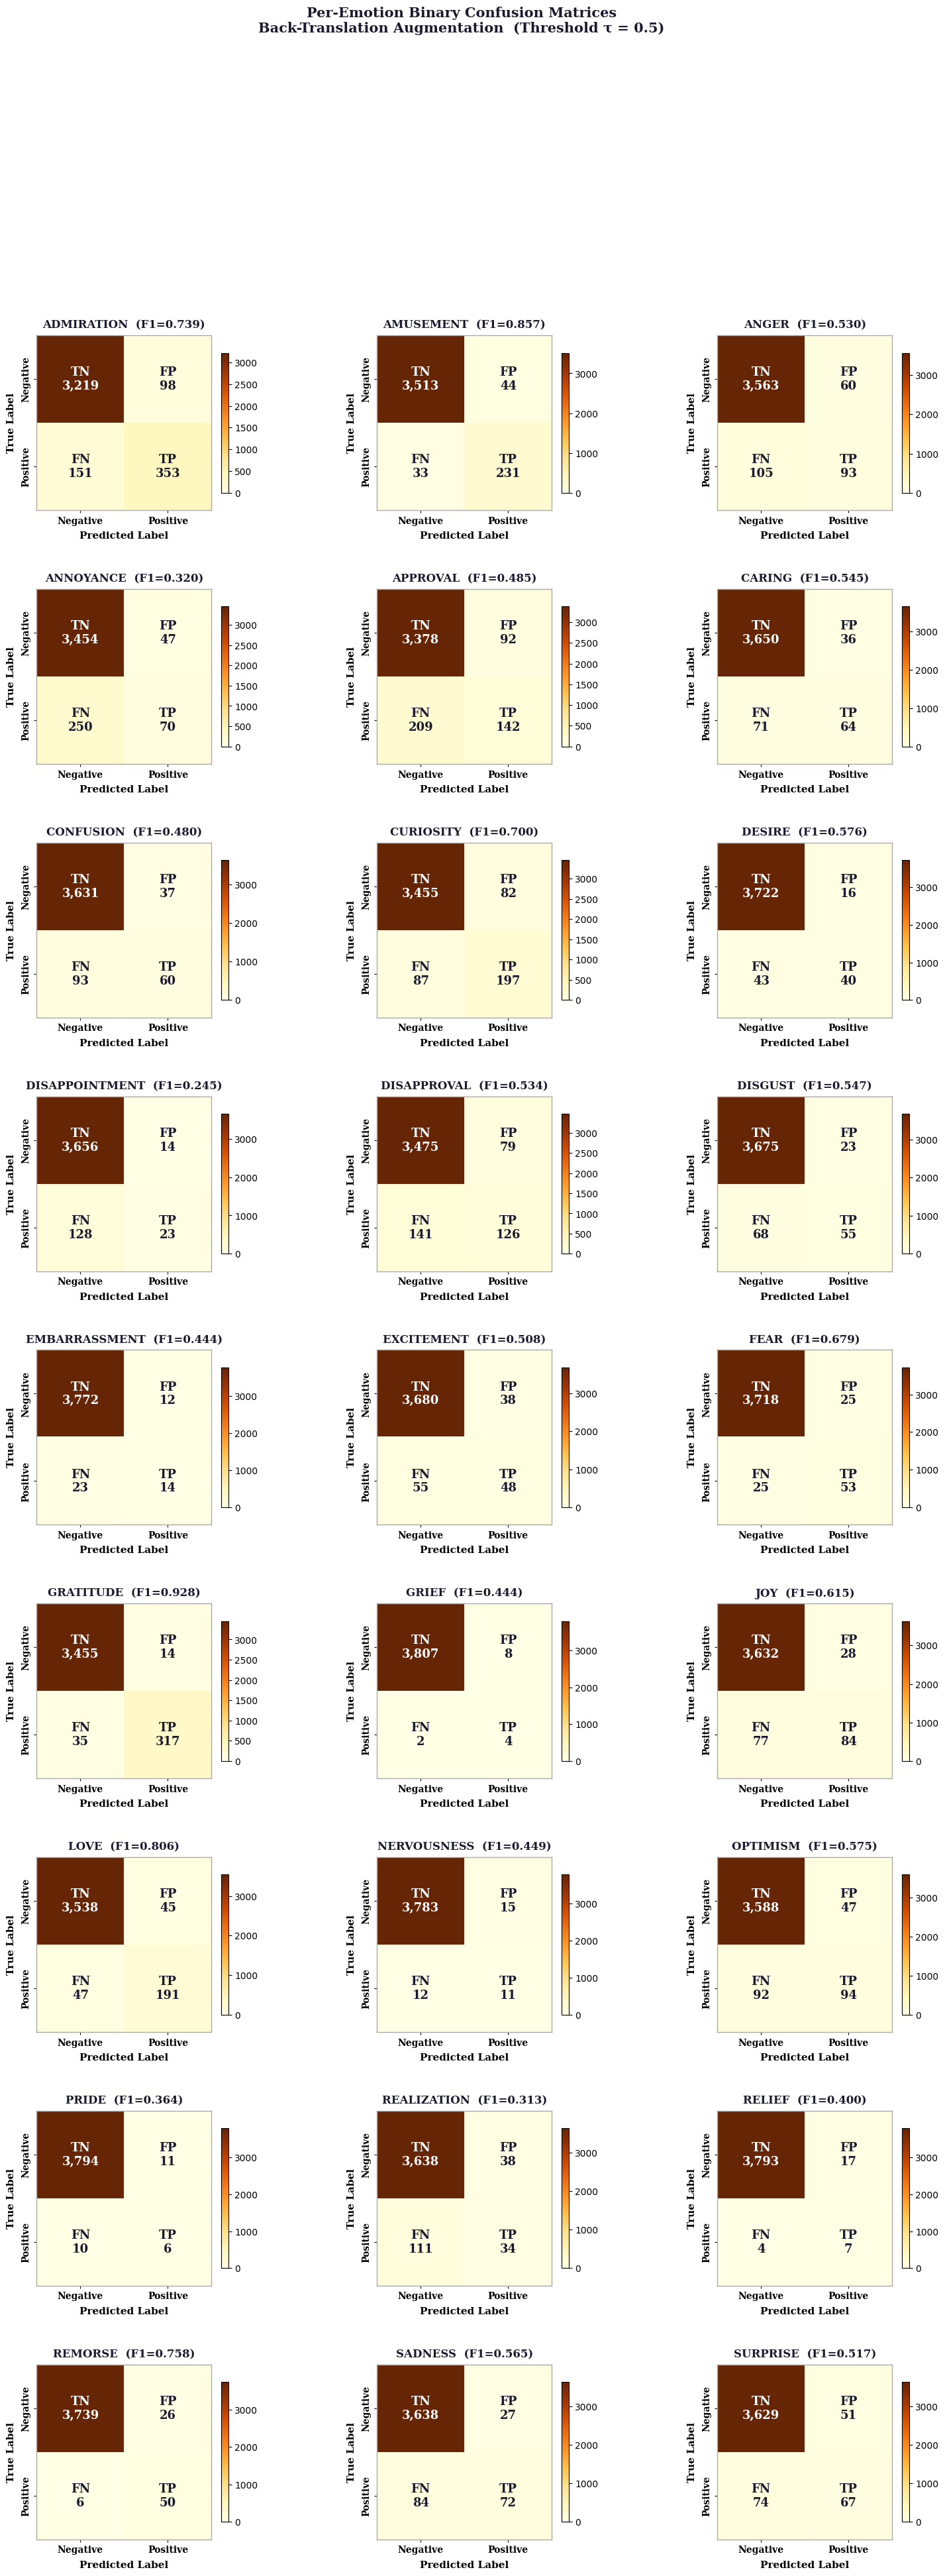

✅ Saved: /kaggle/working/fig_cm_per_emotion_augmentationFIN.png
   Size:   3.42 MB
   DPI:    600
   Layout: 9 rows × 3 cols
✅ Clean — no metrics below plots


In [76]:
# ============================================================
# JOURNAL READY — Per Emotion Confusion Matrix
# CLEAN — title only, no metrics anywhere
# 3 per row
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import (
    confusion_matrix, f1_score
)
import os

OUTPUT_PATH = "/kaggle/working"

n_emotions = len(EMOTION_NAMES_NO_NEUTRAL)
n_cols     = 3
n_rows     = (n_emotions + n_cols - 1) // n_cols

fig = plt.figure(figsize=(18, n_rows * 4.8))
fig.patch.set_facecolor("white")

gs = gridspec.GridSpec(
    n_rows, n_cols,
    figure=fig,
    hspace=0.45,
    wspace=0.40
)

for i, emotion in enumerate(
    EMOTION_NAMES_NO_NEUTRAL
):
    row = i // n_cols
    col = i %  n_cols
    ax  = fig.add_subplot(gs[row, col])

    y_true = test_emotion_labels[:, i]
    y_pred = preds_aug[:, i]

    cm = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    )

    tn = cm[0, 0]
    fp = cm[0, 1]
    fn = cm[1, 0]
    tp = cm[1, 1]

    f1 = f1_score(
        y_true, y_pred, zero_division=0
    )

    # ── Heatmap ───────────────────────────────────
    im = ax.imshow(
        cm,
        interpolation="nearest",
        cmap="YlOrBr",
        vmin=0,
        aspect="equal"
    )

    plt.colorbar(
        im, ax=ax,
        shrink=0.80,
        pad=0.04
    )

    # ── Title only — emotion + F1 ─────────────────
    ax.set_title(
        f"{emotion.upper()}  (F1={f1:.3f})",
        fontsize=12,
        fontweight="bold",
        fontfamily="serif",
        color="#1A1A2E",
        pad=8
    )

    # ── Axis labels ───────────────────────────────
    ax.set_xlabel(
        "Predicted Label",
        fontsize=11,
        fontweight="bold",
        fontfamily="serif",
        labelpad=6
    )
    ax.set_ylabel(
        "True Label",
        fontsize=11,
        fontweight="bold",
        fontfamily="serif",
        labelpad=6
    )

    # ── Tick labels ───────────────────────────────
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(
        ["Negative", "Positive"],
        fontsize=10,
        fontfamily="serif",
        fontweight="bold"
    )
    ax.set_yticklabels(
        ["Negative", "Positive"],
        fontsize=10,
        fontfamily="serif",
        fontweight="bold",
        rotation=90,
        va="center"
    )

    ax.tick_params(
        length=3,
        width=0.8
    )

    # ── Spines ────────────────────────────────────
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)
        spine.set_color("#AAAAAA")

    # ── Cell labels TN FP FN TP ───────────────────
    cell_labels = [
        [f"TN\n{tn:,}", f"FP\n{fp:,}"],
        [f"FN\n{fn:,}", f"TP\n{tp:,}"]
    ]

    thresh = cm.max() / 2.0

    for r in range(2):
        for c in range(2):
            ax.text(
                c, r,
                cell_labels[r][c],
                ha="center",
                va="center",
                fontsize=13,
                fontweight="bold",
                fontfamily="serif",
                color="white"
                if cm[r, c] > thresh
                else "#1A1A2E"
            )

# ── Hide empty subplots ───────────────────────────────────
total = n_rows * n_cols
for j in range(n_emotions, total):
    row = j // n_cols
    col = j %  n_cols
    fig.add_subplot(
        gs[row, col]
    ).set_visible(False)

# ── Main title ────────────────────────────────────────────
fig.suptitle(
    "Per-Emotion Binary Confusion Matrices\n"
    "Back-Translation Augmentation  "
    "(Threshold τ = 0.5)",
    fontsize=15,
    fontweight="bold",
    fontfamily="serif",
    color="#1A1A2E",
    y=0.995
)

# ── Save ──────────────────────────────────────────────────
SAVE_FILE = os.path.join(
    OUTPUT_PATH,
    "fig_cm_per_emotion_augmentationFIN.png"
)

plt.savefig(
    SAVE_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    edgecolor="none"
)
plt.show()

size = os.path.getsize(SAVE_FILE)
print(f"✅ Saved: {SAVE_FILE}")
print(f"   Size:   {size/1e6:.2f} MB")
print(f"   DPI:    600")
print(f"   Layout: {n_rows} rows × {n_cols} cols")
print(f"✅ Clean — no metrics below plots")


In [80]:
# ============================================================
# DISABLE PIL BOMB CHECK
# ============================================================

from PIL import Image
import os

# Disable the limit
Image.MAX_IMAGE_PIXELS = None

SAVE_FILE = "/kaggle/working/fig_cm_per_emotion_augmentationFIN.png"

img  = Image.open(SAVE_FILE)
size = os.path.getsize(SAVE_FILE)

print(f"File size:   {size/1e6:.2f} MB")
print(f"Dimensions:  {img.size[0]} x "
      f"{img.size[1]} pixels")
print(f"\nAt 300 DPI:")
print(f"  Width:  {img.size[0]/300:.1f} inches")
print(f"  Height: {img.size[1]/300:.1f} inches")
print(f"\n✅ High resolution confirmed")

File size:   3.42 MB
Dimensions:  8567 x 23333 pixels

At 300 DPI:
  Width:  28.6 inches
  Height: 77.8 inches

✅ High resolution confirmed


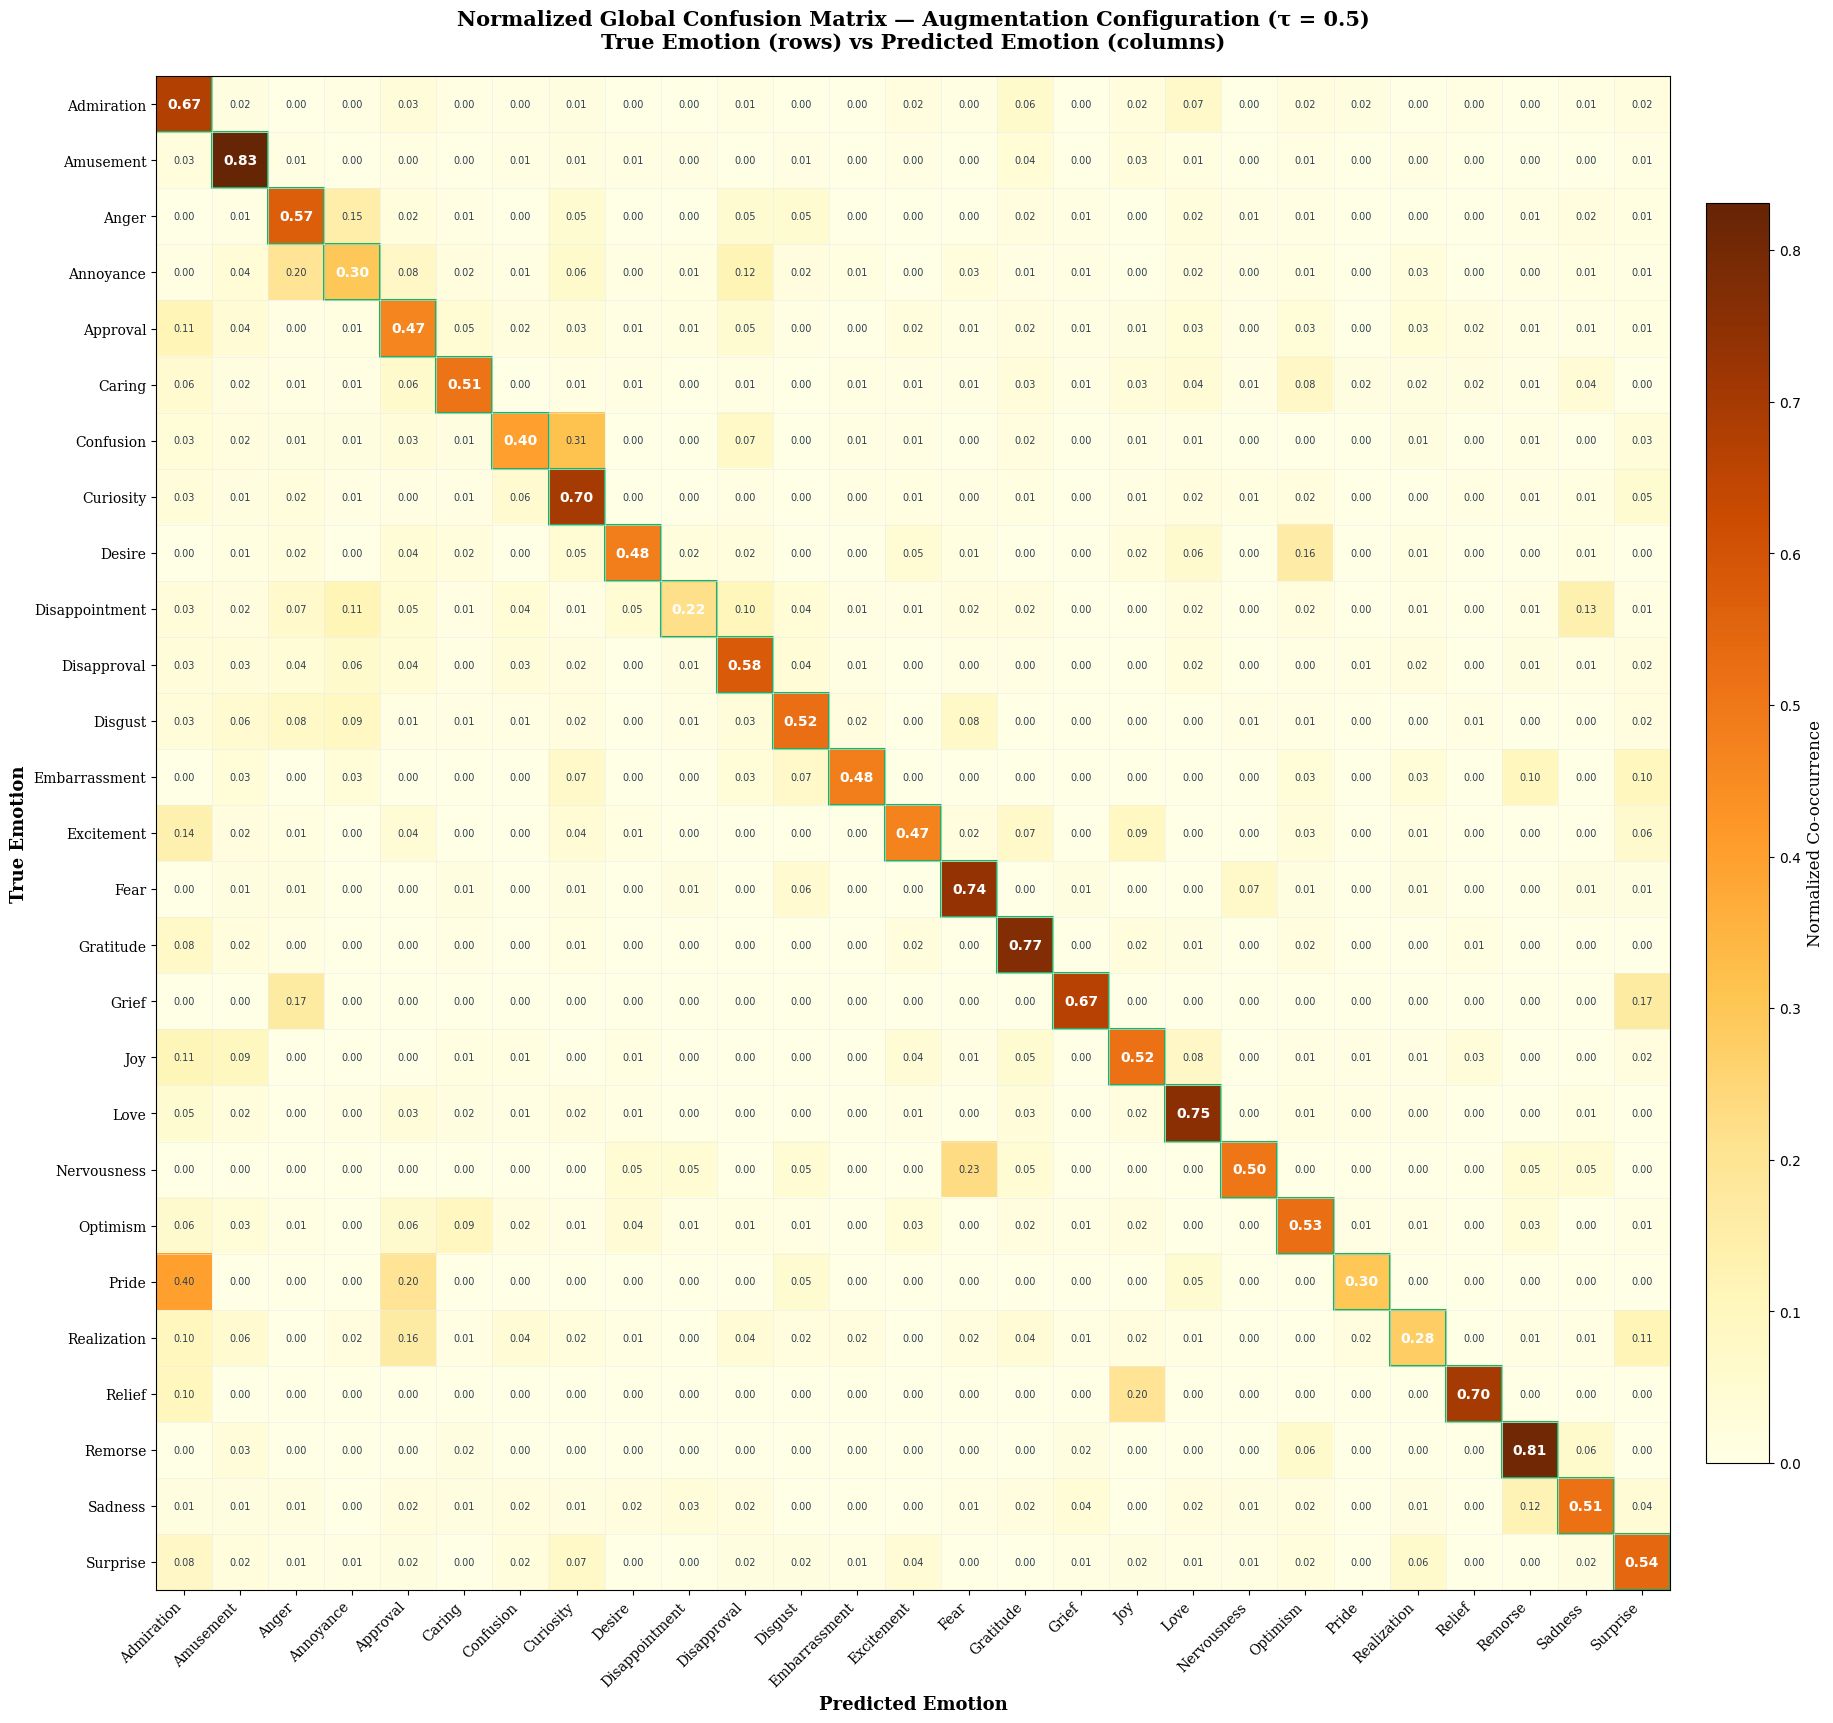

✅ Saved: /kaggle/working/fig_global_cm_normalized.png
   Normalized values with two decimals
   Diagonal values bold
   Journal-ready confusion matrix


In [85]:
# ============================================================
# JOURNAL READY — Normalized Global Confusion Matrix
# ============================================================

n = len(EMOTION_NAMES_NO_NEUTRAL)

# ── Build global confusion matrix ───────────────────────────
global_cm = np.zeros((n, n), dtype=int)

for idx in range(len(test_emotion_labels)):

    true_e = np.where(test_emotion_labels[idx] == 1)[0]
    pred_e = np.where(preds_aug[idx] == 1)[0]

    for t in true_e:
        for p in pred_e:
            global_cm[t, p] += 1


# ── Normalize row-wise ──────────────────────────────────────
row_sums = global_cm.sum(axis=1, keepdims=True)

cm_norm = np.divide(
    global_cm,
    row_sums,
    where=row_sums != 0
)


# ── Plot ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 18))
fig.patch.set_facecolor("white")

im = ax.imshow(
    cm_norm,
    cmap="YlOrBr",
    interpolation="nearest",
    aspect="equal"
)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label(
    "Normalized Co-occurrence",
    fontsize=12,
    fontfamily="serif"
)

# Title
ax.set_title(
    "Normalized Global Confusion Matrix — Augmentation Configuration (τ = 0.5)\n"
    "True Emotion (rows) vs Predicted Emotion (columns)",
    fontsize=15,
    fontweight="bold",
    fontfamily="serif",
    pad=20
)

# Axis labels
ax.set_xlabel(
    "Predicted Emotion",
    fontsize=13,
    fontweight="bold",
    fontfamily="serif"
)

ax.set_ylabel(
    "True Emotion",
    fontsize=13,
    fontweight="bold",
    fontfamily="serif"
)


# Ticks
ax.set_xticks(range(n))
ax.set_yticks(range(n))

ax.set_xticklabels(
    [e.capitalize() for e in EMOTION_NAMES_NO_NEUTRAL],
    rotation=45,
    ha="right",
    fontsize=10,
    fontfamily="serif"
)

ax.set_yticklabels(
    [e.capitalize() for e in EMOTION_NAMES_NO_NEUTRAL],
    fontsize=10,
    fontfamily="serif"
)


# ── Write values in ALL cells ───────────────────────────────
for i in range(n):
    for j in range(n):

        val = cm_norm[i, j]

        if i == j:  # diagonal values
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                fontweight="bold",
                color="white"
            )

        else:
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=7,
                color="#2C3E50"
            )


# ── Highlight diagonal ──────────────────────────────────────
for i in range(n):
    ax.add_patch(
        plt.Rectangle(
            (i - 0.5, i - 0.5),
            1,
            1,
            fill=False,
            edgecolor="#27AE60",
            linewidth=1.5
        )
    )


# Grid lines
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)

ax.grid(
    which="minor",
    color="#EAECEE",
    linestyle="-",
    linewidth=0.4
)

ax.tick_params(which="minor", bottom=False, left=False)


# Layout
plt.tight_layout()


# ── Save figure ─────────────────────────────────────────────
SAVE_FILE = os.path.join(
    OUTPUT_PATH,
    "fig_global_cm_normalized.png"
)

plt.savefig(
    SAVE_FILE,
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


print(f"✅ Saved: {SAVE_FILE}")
print("   Normalized values with two decimals")
print("   Diagonal values bold")
print("   Journal-ready confusion matrix")

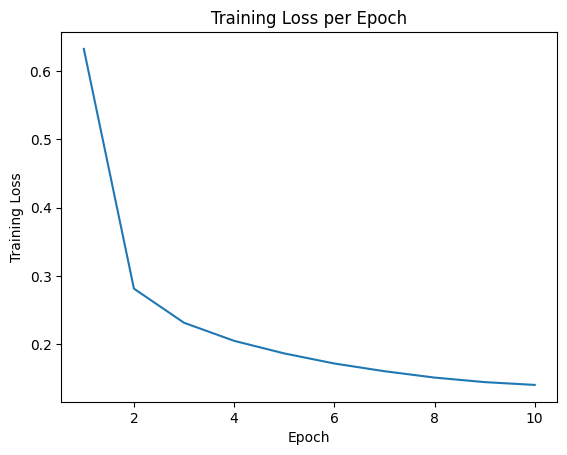

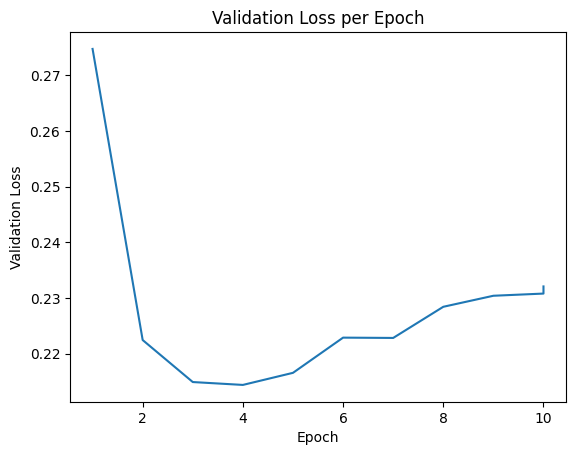

In [86]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert log history to DataFrame
log_history = pd.DataFrame(trainer.state.log_history)

# Extract training and validation logs
train_logs = log_history[log_history["loss"].notna()]
val_logs = log_history[log_history["eval_loss"].notna()]

# Plot training loss
plt.figure()
plt.plot(train_logs["epoch"], train_logs["loss"])
plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.show()

# Plot validation loss
plt.figure()
plt.plot(val_logs["epoch"], val_logs["eval_loss"])
plt.title("Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.show()

In [ ]:
print(log_history.head())

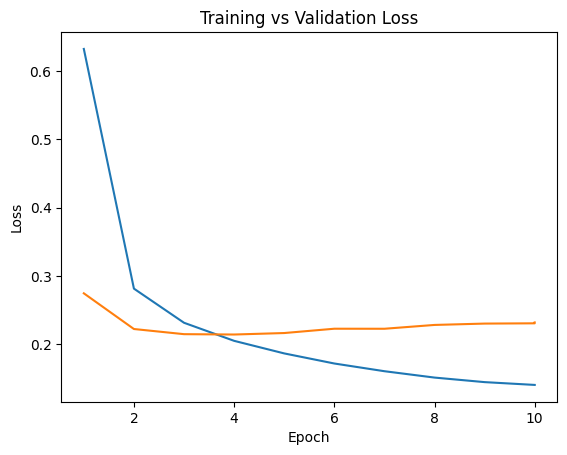

In [87]:
plt.figure()
plt.plot(train_logs["epoch"], train_logs["loss"])
plt.plot(val_logs["epoch"], val_logs["eval_loss"])
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

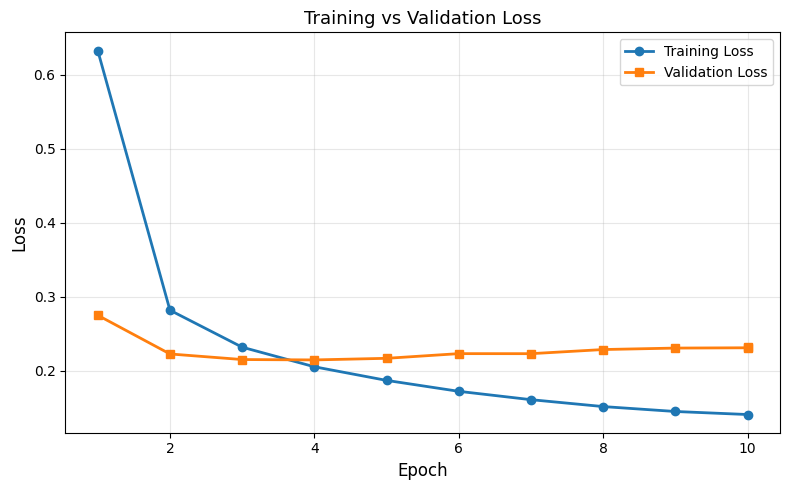

In [90]:
plt.figure(figsize=(8,5))

plt.plot(train_logs["epoch"], train_logs["loss"],
         marker='o', linewidth=2,
         label="Training Loss")

plt.plot(val_logs["epoch"], val_logs["eval_loss"],
         marker='s', linewidth=2,
         label="Validation Loss")

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)

plt.title("Training vs Validation Loss", fontsize=13)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

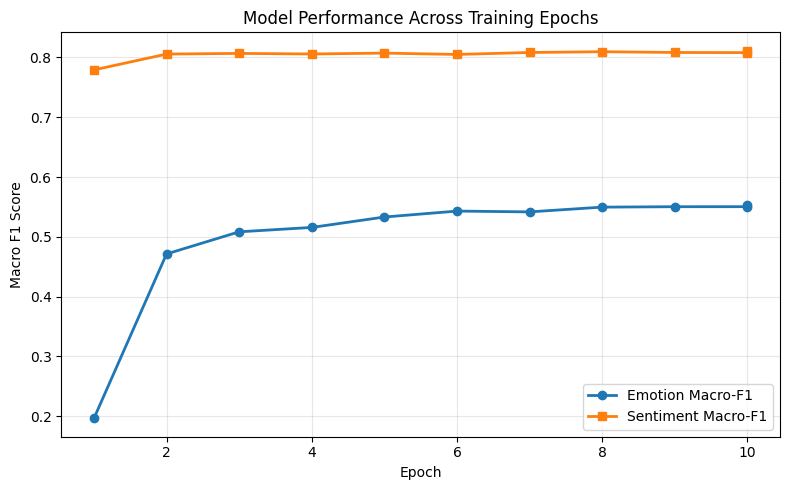

In [92]:
plt.figure(figsize=(8,5))

plt.plot(val_logs["epoch"],
         val_logs["eval_emotion_macro_f1"],
         marker="o",
         linewidth=2,
         label="Emotion Macro-F1")

plt.plot(val_logs["epoch"],
         val_logs["eval_sentiment_macro_f1"],
         marker="s",
         linewidth=2,
         label="Sentiment Macro-F1")

plt.xlabel("Epoch")
plt.ylabel("Macro F1 Score")

plt.title("Model Performance Across Training Epochs")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [93]:
best_epoch = val_logs.loc[
    val_logs["eval_emotion_macro_f1"].idxmax(),
    "epoch"
]

best_f1 = val_logs["eval_emotion_macro_f1"].max()

print(f"Best Epoch: {int(best_epoch)}")
print(f"Best Emotion Macro-F1: {best_f1:.4f}")

Best Epoch: 10
Best Emotion Macro-F1: 0.5528


In [99]:
val_outputs = trainer.predict(validation_dataset)

val_emotion_logits = val_outputs.predictions[0]
val_sentiment_logits = val_outputs.predictions[1]

val_emotion_labels = val_outputs.label_ids[0]
val_sentiment_labels = val_outputs.label_ids[1]

In [100]:
import torch
import numpy as np
from sklearn.metrics import f1_score

val_emotion_probs = torch.sigmoid(
    torch.tensor(val_emotion_logits)
).numpy()

val_sentiment_probs = torch.sigmoid(
    torch.tensor(val_sentiment_logits)
).numpy()

val_emotion_preds = (val_emotion_probs > 0.5).astype(int)
val_sentiment_preds = (val_sentiment_probs > 0.5).astype(int)

In [101]:
emotion_f1_scores = []

for i in range(27):
    f1 = f1_score(
        val_emotion_labels[:, i],
        val_emotion_preds[:, i],
        zero_division=0
    )
    emotion_f1_scores.append(f1)

for name, score in zip(EMOTION_NAMES_NO_NEUTRAL, emotion_f1_scores):
    print(f"{name}: {score:.4f}")

admiration: 0.7565
amusement: 0.8098
anger: 0.5568
annoyance: 0.3063
approval: 0.4020
caring: 0.5393
confusion: 0.4810
curiosity: 0.6752
desire: 0.6040
disappointment: 0.2634
disapproval: 0.4917
disgust: 0.4795
embarrassment: 0.5278
excitement: 0.4103
fear: 0.7134
gratitude: 0.9188
grief: 0.4375
joy: 0.5507
love: 0.8000
nervousness: 0.4231
optimism: 0.5983
pride: 0.5926
realization: 0.3258
relief: 0.3111
remorse: 0.7121
sadness: 0.5564
surprise: 0.6173


In [102]:
sentiment_f1_scores = []

for i, name in enumerate(["Positive", "Negative", "Ambiguous"]):
    f1 = f1_score(
        val_sentiment_labels[:, i],
        val_sentiment_preds[:, i],
        zero_division=0
    )
    sentiment_f1_scores.append(f1)
    print(f"{name}: {f1:.4f}")

Positive: 0.8989
Negative: 0.8194
Ambiguous: 0.7062


In [103]:
test_outputs = trainer.predict(test_dataset)

test_emotion_logits = test_outputs.predictions[0]
test_sentiment_logits = test_outputs.predictions[1]

test_emotion_labels = test_outputs.label_ids[0]
test_sentiment_labels = test_outputs.label_ids[1]

test_emotion_probs = torch.sigmoid(
    torch.tensor(test_emotion_logits)
).numpy()

test_sentiment_probs = torch.sigmoid(
    torch.tensor(test_sentiment_logits)
).numpy()

test_emotion_preds = (test_emotion_probs > 0.5).astype(int)
test_sentiment_preds = (test_sentiment_probs > 0.5).astype(int)

In [104]:
from sklearn.metrics import f1_score

emotion_f1_scores = f1_score(
    test_emotion_labels,
    test_emotion_preds,
    average=None,
    zero_division=0
)

print("\n===== Per Emotion F1 (Test) =====")

for name, score in zip(EMOTION_NAMES_NO_NEUTRAL, emotion_f1_scores):
    print(f"{name}: {score:.4f}")


===== Per Emotion F1 (Test) =====
admiration: 0.7393
amusement: 0.8571
anger: 0.5299
annoyance: 0.3204
approval: 0.4855
caring: 0.5447
confusion: 0.4800
curiosity: 0.6998
desire: 0.5755
disappointment: 0.2447
disapproval: 0.5339
disgust: 0.5473
embarrassment: 0.4444
excitement: 0.5079
fear: 0.6795
gratitude: 0.9283
grief: 0.4444
joy: 0.6154
love: 0.8059
nervousness: 0.4490
optimism: 0.5749
pride: 0.3636
realization: 0.3134
relief: 0.4000
remorse: 0.7576
sadness: 0.5647
surprise: 0.5174


In [105]:
SENTIMENT_NAMES = ["positive", "negative", "ambiguous"]

In [106]:
sentiment_f1_scores = f1_score(
    test_sentiment_labels,
    test_sentiment_preds,
    average=None,
    zero_division=0
)

print("\n===== Per Sentiment F1 (Test) =====")

for name, score in zip(SENTIMENT_NAMES, sentiment_f1_scores):
    print(f"{name}: {score:.4f}")


===== Per Sentiment F1 (Test) =====
positive: 0.9013
negative: 0.8235
ambiguous: 0.7091


In [107]:
print("\nLowest 5 Emotion F1 Scores:")

lowest_indices = np.argsort(emotion_f1_scores)[:5]

for i in lowest_indices:
    print(EMOTION_NAMES_NO_NEUTRAL[i], emotion_f1_scores[i])


Lowest 5 Emotion F1 Scores:
disappointment 0.24468085106382978
realization 0.31336405529953915
annoyance 0.32036613272311215
pride 0.36363636363636365
relief 0.4


# THRESHOLD TUNING

In [108]:
val_outputs = trainer.predict(validation_dataset)

val_emotion_logits = val_outputs.predictions[0]
val_emotion_labels = val_outputs.label_ids[0]

val_probs = torch.sigmoid(
    torch.tensor(val_emotion_logits)
).numpy()

In [109]:
from sklearn.metrics import f1_score

best_thresholds = []

for i in range(27):

    best_f1 = 0
    best_t = 0.5

    for t in np.arange(0.1, 0.9, 0.05):

        preds = (val_probs[:, i] > t).astype(int)

        f1 = f1_score(
            val_emotion_labels[:, i],
            preds,
            zero_division=0
        )

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    best_thresholds.append(best_t)

best_thresholds = np.array(best_thresholds)

print("Best thresholds per emotion:")
print(best_thresholds)

Best thresholds per emotion:
[0.4  0.25 0.3  0.15 0.15 0.15 0.3  0.2  0.65 0.15 0.3  0.35 0.55 0.45
 0.5  0.4  0.8  0.2  0.3  0.85 0.2  0.8  0.75 0.6  0.3  0.35 0.5 ]


In [110]:
test_outputs = trainer.predict(test_dataset)

test_emotion_logits = test_outputs.predictions[0]
test_sentiment_logits = test_outputs.predictions[1]

test_emotion_labels = test_outputs.label_ids[0]
test_sentiment_labels = test_outputs.label_ids[1]

test_emotion_probs = torch.sigmoid(
    torch.tensor(test_emotion_logits)
).numpy()

test_sentiment_probs = torch.sigmoid(
    torch.tensor(test_sentiment_logits)
).numpy()

# Apply tuned thresholds for emotion
test_emotion_preds = (test_emotion_probs > best_thresholds).astype(int)

# Sentiment can remain 0.5 unless you tune separately
test_sentiment_preds = (test_sentiment_probs > 0.5).astype(int)

In [111]:
from sklearn.metrics import f1_score

emotion_macro_f1_tuned = f1_score(
    test_emotion_labels,
    test_emotion_preds,
    average="macro",
    zero_division=0
)

sentiment_macro_f1 = f1_score(
    test_sentiment_labels,
    test_sentiment_preds,
    average="macro",
    zero_division=0
)

print("\n===== FINAL TEST RESULTS (TUNED) =====")
print("Emotion Macro F1:", emotion_macro_f1_tuned)
print("Sentiment Macro F1:", sentiment_macro_f1)


===== FINAL TEST RESULTS (TUNED) =====
Emotion Macro F1: 0.5604443893948465
Sentiment Macro F1: 0.8113347687154612


In [112]:
emotion_f1_scores = f1_score(
    test_emotion_labels,
    test_emotion_preds,
    average=None,
    zero_division=0
)

print("\n===== Per Emotion F1 (Tuned Test) =====")

for name, score in zip(EMOTION_NAMES_NO_NEUTRAL, emotion_f1_scores):
    print(f"{name}: {score:.4f}")


===== Per Emotion F1 (Tuned Test) =====
admiration: 0.7433
amusement: 0.8561
anger: 0.5512
annoyance: 0.4393
approval: 0.5188
caring: 0.5067
confusion: 0.4878
curiosity: 0.7064
desire: 0.5588
disappointment: 0.3155
disapproval: 0.5414
disgust: 0.5664
embarrassment: 0.4444
excitement: 0.4898
fear: 0.6795
gratitude: 0.9289
grief: 0.4000
joy: 0.6229
love: 0.8169
nervousness: 0.3810
optimism: 0.6000
pride: 0.4286
realization: 0.2473
relief: 0.4516
remorse: 0.7482
sadness: 0.5839
surprise: 0.5174


In [113]:
import numpy as np

print("\n===== Lowest 5 Emotion F1 (Tuned Test) =====")

lowest_indices = np.argsort(emotion_f1_scores)[:5]

for i in lowest_indices:
    print(EMOTION_NAMES_NO_NEUTRAL[i],
          round(emotion_f1_scores[i], 4))


===== Lowest 5 Emotion F1 (Tuned Test) =====
realization 0.2473
disappointment 0.3155
nervousness 0.381
grief 0.4
pride 0.4286


In [114]:
bottom5_avg = np.mean(
    emotion_f1_scores[lowest_indices]
)

print("\nAverage F1 of Lowest 5 Classes:",
      round(bottom5_avg, 4))


Average F1 of Lowest 5 Classes: 0.3545


In [115]:
# ============================================================
# SAVE EVERYTHING AFTER THRESHOLD TUNING + ZIP
# Run this as FINAL cell after tuning
# ============================================================

import os
import json
import zipfile
import numpy as np
import torch
import pandas as pd

SAVE_PATH = "/kaggle/working/journal_model_aug_TUNING_bt"
ZIP_PATH  = "/kaggle/working/journal_model_augTUNING_bt.zip"

os.makedirs(SAVE_PATH, exist_ok=True)

print("=" * 55)
print("SAVING ALL FILES AFTER TUNING")
print("=" * 55)

# ── 1. Model weights ──────────────────────────────────────
trainer.save_model(SAVE_PATH)
print("✅ Model weights saved")

# ── 2. Tokenizer ──────────────────────────────────────────
tokenizer.save_pretrained(SAVE_PATH)
print("✅ Tokenizer saved")

# ── 3. Training args ──────────────────────────────────────
with open(
    os.path.join(SAVE_PATH,
                 "training_args.json"), "w"
) as f:
    json.dump(
        training_args.to_dict(), f, indent=2
    )
print("✅ Training args saved")

# ── 4. Best thresholds ────────────────────────────────────
np.save(
    os.path.join(SAVE_PATH,
                 "best_thresholds.npy"),
    best_thresholds
)
print("✅ Best thresholds saved")

# ── 5. Test predictions ───────────────────────────────────
test_out = trainer.predict(test_dataset)

test_emotion_logits   = test_out.predictions[0]
test_sentiment_logits = test_out.predictions[1]
test_emotion_labels   = test_out.label_ids[0]
test_sentiment_labels = test_out.label_ids[1]

test_emotion_probs = torch.sigmoid(
    torch.tensor(test_emotion_logits)
).numpy()
test_sentiment_probs = torch.sigmoid(
    torch.tensor(test_sentiment_logits)
).numpy()

# Predictions
test_preds_05    = (
    test_emotion_probs > 0.5
).astype(int)
test_preds_tuned = (
    test_emotion_probs > best_thresholds
).astype(int)

np.save(os.path.join(SAVE_PATH,
        "test_emotion_logits.npy"),
        test_emotion_logits)
np.save(os.path.join(SAVE_PATH,
        "test_emotion_labels.npy"),
        test_emotion_labels)
np.save(os.path.join(SAVE_PATH,
        "test_emotion_probs.npy"),
        test_emotion_probs)
np.save(os.path.join(SAVE_PATH,
        "test_preds_05.npy"),
        test_preds_05)
np.save(os.path.join(SAVE_PATH,
        "test_preds_tuned.npy"),
        test_preds_tuned)
np.save(os.path.join(SAVE_PATH,
        "test_sentiment_logits.npy"),
        test_sentiment_logits)
np.save(os.path.join(SAVE_PATH,
        "test_sentiment_labels.npy"),
        test_sentiment_labels)
np.save(os.path.join(SAVE_PATH,
        "test_sentiment_probs.npy"),
        test_sentiment_probs)
print("✅ Test predictions saved")
print("✅ Test labels saved")
print("✅ Test probabilities saved")

# ── 6. Validation predictions ─────────────────────────────
val_out = trainer.predict(validation_dataset)

val_emotion_logits = val_out.predictions[0]
val_emotion_labels = val_out.label_ids[0]

val_emotion_probs = torch.sigmoid(
    torch.tensor(val_emotion_logits)
).numpy()

np.save(os.path.join(SAVE_PATH,
        "val_emotion_logits.npy"),
        val_emotion_logits)
np.save(os.path.join(SAVE_PATH,
        "val_emotion_labels.npy"),
        val_emotion_labels)
np.save(os.path.join(SAVE_PATH,
        "val_emotion_probs.npy"),
        val_emotion_probs)
print("✅ Validation predictions saved")

# ── 7. Emotion counts ─────────────────────────────────────
np.save(
    os.path.join(SAVE_PATH,
                 "emotion_counts_balanced.npy"),
    emotion_counts_balanced
)
print("✅ Emotion counts saved")

# ── 8. Training log ───────────────────────────────────────
log_df = pd.DataFrame(
    trainer.state.log_history
)
log_df.to_csv(
    os.path.join(SAVE_PATH,
                 "training_log.csv"),
    index=False
)
print("✅ Training log saved")

# ── 9. Emotion names ──────────────────────────────────────
with open(
    os.path.join(SAVE_PATH,
                 "emotion_names.json"), "w"
) as f:
    json.dump(EMOTION_NAMES_NO_NEUTRAL, f)
print("✅ Emotion names saved")

# ── 10. Augmentation stats ────────────────────────────────
aug_stats = {
    "original_train":       len(texts),
    "augmented_before":     len(augmented_texts),
    "removed_by_filter":    len(augmented_texts) -
                            len(filtered_texts),
    "augmented_after":      len(filtered_texts),
    "final_train":          len(balanced_texts),
    "increase_percent":     round(
        100*(len(balanced_texts)-len(texts))
        /len(texts), 2
    ),
    "imbalance_before":     round(
        float(counts.max()/counts.min()), 2
    ),
    "imbalance_after":      round(
        float(new_counts.max()/
              new_counts.min()), 2
    ),
    "mean_cosine_sim":      round(
        float(cos_scores.mean()), 4
    ),
    "duplicate_rate":       6.4,
    "bt_languages":         [
        m["lang"] for m in loaded_models
    ],
    "num_languages":        len(loaded_models),
    "similarity_threshold": 0.6,
    "target_min":           1000
}

with open(
    os.path.join(SAVE_PATH,
                 "aug_stats.json"), "w"
) as f:
    json.dump(aug_stats, f, indent=2)
print("✅ Augmentation stats saved")


# ── List all files ────────────────────────────────────────
print(f"\n{'='*55}")
print(f"ALL SAVED FILES")
print(f"{'='*55}")

total_size = 0
for f in sorted(os.listdir(SAVE_PATH)):
    size = os.path.getsize(
        os.path.join(SAVE_PATH, f)
    )
    total_size += size
    if size < 1024 * 1024:
        size_str = f"{size/1024:.1f} KB"
    else:
        size_str = f"{size/1e6:.1f} MB"
    print(f"  {f:<45} {size_str:>10}")

print(f"\n  Total: {total_size/1e6:.1f} MB")

# ── ZIP everything ────────────────────────────────────────
print(f"\n{'='*55}")
print(f"CREATING ZIP")
print(f"{'='*55}")

with zipfile.ZipFile(
    ZIP_PATH, "w",
    zipfile.ZIP_DEFLATED
) as zipf:
    for root, dirs, files in os.walk(SAVE_PATH):
        for file in files:
            file_path = os.path.join(root, file)
            arcname   = os.path.relpath(
                file_path, SAVE_PATH
            )
            zipf.write(file_path, arcname)
            print(f"  Added: {arcname}")

zip_size = os.path.getsize(ZIP_PATH)

print(f"\n{'='*55}")
print(f"COMPLETE")
print(f"{'='*55}")
print(f"Zip:         {ZIP_PATH}")
print(f"Zip size:    {zip_size/1e6:.1f} MB")
print(f"\n✅ Download from Kaggle Output tab:")
print(f"   journal_model_aug_bt.zip")
print(f"\nContains:")
print(f"  ✅ Model weights")
print(f"  ✅ Tokenizer")
print(f"  ✅ Best thresholds")
print(f"  ✅ Test predictions + labels + probs")
print(f"  ✅ Validation predictions")
print(f"  ✅ Training log")
print(f"  ✅ Emotion names")
print(f"  ✅ Augmentation stats")
print(f"  ✅ Confusion matrix figures")

SAVING ALL FILES AFTER TUNING
✅ Model weights saved
✅ Tokenizer saved
✅ Training args saved
✅ Best thresholds saved


✅ Test predictions saved
✅ Test labels saved
✅ Test probabilities saved


✅ Validation predictions saved
✅ Emotion counts saved
✅ Training log saved
✅ Emotion names saved
✅ Augmentation stats saved

ALL SAVED FILES
  aug_stats.json                                    0.4 KB
  best_thresholds.npy                               0.3 KB
  emotion_counts_balanced.npy                       0.3 KB
  emotion_names.json                                0.3 KB
  model.safetensors                               438.1 MB
  test_emotion_labels.npy                         403.1 KB
  test_emotion_logits.npy                         403.1 KB
  test_emotion_probs.npy                          403.1 KB
  test_preds_05.npy                               806.1 KB
  test_preds_tuned.npy                            806.1 KB
  test_sentiment_labels.npy                        44.9 KB
  test_sentiment_logits.npy                        44.9 KB
  test_sentiment_probs.npy                         44.9 KB
  tokenizer.json                                  695.0 KB
  tokenizer_config.json          